# 🦯 AI-Powered Blind Assistance Device
## Edge AI Project — CP330
### Deployment Target: Arduino Nicla Vision (STM32H747, 1MB RAM, 2MB Flash)

---

**Project Goal:** Build a real-time object classification system that assists visually impaired individuals.
The device will be mounted on a helmet and provide audio/haptic feedback about surrounding objects.

**Dataset:** 10 classes (~2840 images) — Bag, Book, Bottle, Clear Path, Dustbin, Human, Laptop, Obstacle, Pen, Shoes

**Techniques Used (from Lab Sessions):**
| Lab | Technique | Application |
|-----|-----------|-------------|
| Lab 02 | TinyML Pipeline | Model development & deployment flow |
| Lab 03 | Embedded CV | Image preprocessing for edge |
| Lab 04 | Decision Tree | Baseline classifier |
| Lab 05 | ANN/CNN + Transfer Learning | CNN from scratch + MobileNetV2 teacher |
| Lab 06 | Model Efficiency Metrics | FLOPs, MACs, parameter analysis |
| Lab 07 | Quantization | Post-training INT8 quantization |
| Lab 08 | Quantization Aware Training | QAT for accuracy preservation |
| Lab 09 | Pruning | Magnitude-based weight pruning |
| Lab 10 | Knowledge Distillation | Teacher-student training |

---

## Section 1: Setup & Configuration
Install all required packages and configure the environment.

In [1]:
# ============================================================================
# SECTION 1: SETUP & CONFIGURATION
# ============================================================================

!pip install tensorflow-model-optimization --quiet
!pip install scikit-learn --quiet
!pip install seaborn --quiet

In [2]:
import os
# 1. Force Keras 2
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_model_optimization as tfmot



print("Keras 2 Loaded. Model recovered successfully!")
#import tensorflow as tf
#import tensorflow_model_optimization as tfmot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import tempfile
import zipfile
import pathlib
import shutil
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"TF Model Optimization version: {tfmot.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Keras 2 Loaded. Model recovered successfully!
TensorFlow version: 2.20.0
TF Model Optimization version: 0.8.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

ORIGINAL_DATASET = '/content/drive/MyDrive/edge_ai_project/dataset'
MERGED_DATASET = '/content/dataset_merged'
MERGE_MAP = {
    'clear_path': ['clear_path'],
    'human':      ['human'],
    'stairs':     ['stairs', 'lift'],
    'obstacle':   ['obstacle', 'table&chair', 'dustbin'],
    'object':     ['bag', 'book', 'bottle', 'shoes'],
    'door':       ['doorwindow'],
}
if os.path.exists(MERGED_DATASET):
    shutil.rmtree(MERGED_DATASET)
for new_class, old_classes in MERGE_MAP.items():
    dst_dir = os.path.join(MERGED_DATASET, new_class)
    os.makedirs(dst_dir, exist_ok=True)
    total = 0
    for old_class in old_classes:
        src_dir = os.path.join(ORIGINAL_DATASET, old_class)
        if not os.path.isdir(src_dir): continue
        for img_name in os.listdir(src_dir):
            if img_name.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                shutil.copy2(os.path.join(src_dir, img_name),
                             os.path.join(dst_dir, old_class+"_"+img_name))
                total += 1
    print(f"  {new_class:15s}: {total:4d} images")
DATASET_PATH = MERGED_DATASET


  clear_path     :  469 images
  human          :  466 images
  stairs         :  652 images
  obstacle       :  767 images
  object         : 1168 images
  door           :  629 images


In [5]:
# ===========================================================================
# CELL: CONFIGURATION (Replace existing config cell)
# ===========================================================================
DATASET_PATH = '/content/dataset_merged'  # Use merged 6-class dataset
OUTPUT_PATH = '/content/drive/MyDrive/edge_ai_project/output'
os.makedirs(OUTPUT_PATH, exist_ok=True)

IMG_SIZE = 96
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 32

# Training configuration
EPOCHS_CNN = 30
EPOCHS_TEACHER = 25
EPOCHS_KD = 30
EPOCHS_QAT = 15

# Knowledge Distillation
TEMPERATURE = 3.0       # Lower T preserves more info (was 5.0)
ALPHA = 0.5             # Balanced soft/hard loss (was 0.7)

# Iterative Pruning — 3 rounds (gentler than one-shot 70%)
#PRUNING_ROUNDS = [
 #   (0.00, 0.20),  # Round 1: 0% → 20%
  #  (0.20, 0.35),  # Round 2: 20% → 35%
   # (0.35, 0.50),  # Round 3: 35% → 50%
#]

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Configuration loaded successfully!")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"  Dataset path: {DATASET_PATH}")
print(f"  Output path: {OUTPUT_PATH}")

Configuration loaded successfully!
  Image size: 96x96x3
  Dataset path: /content/dataset_merged
  Output path: /content/drive/MyDrive/edge_ai_project/output


---
## Section 2: Data Loading & Augmentation (Lab 03 — Embedded CV)

We load images from the class-organized folders and apply data augmentation
techniques suitable for embedded computer vision:
- Rotation, flipping, zoom for robustness
- Brightness shifts to handle varying lighting on the helmet
- 70/15/15 train/validation/test split

In [6]:
# ============================================================================
# SECTION 2: DATA LOADING & AUGMENTATION (Lab 03 - Embedded CV)
# ============================================================================

# Verify dataset exists and list classes
class_names = sorted(os.listdir(DATASET_PATH))
# Filter out any non-directory files
class_names = [c for c in class_names if os.path.isdir(os.path.join(DATASET_PATH, c))]
NUM_CLASSES = len(class_names)

print(f"Found {NUM_CLASSES} classes:")
print("=" * 40)
total_samples = 0
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    n_images = len([f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
    total_samples += n_images
    print(f"  {cls:20s}: {n_images:4d} images")
print("=" * 40)
print(f"  Total: {total_samples} images")

Found 6 classes:
  clear_path          :  469 images
  door                :  629 images
  human               :  466 images
  object              : 1168 images
  obstacle            :  767 images
  stairs              :  652 images
  Total: 4151 images


In [7]:
# Data augmentation for training — critical for small datasets
# These augmentations simulate real-world helmet-mounted camera variations
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=25.0,   # NEW: color robustness
    fill_mode='nearest',
    validation_split=0.15
)

# No augmentation for test data — only rescale
test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [8]:
# --- MANUAL TRAIN / TEST SPLIT ---
# We first separate 15% of data into a test set, then use the remaining
# 85% with a further validation_split for train/val.

import shutil
from sklearn.model_selection import train_test_split as sk_split

SPLIT_DIR = '/content/dataset_split'
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
TEST_DIR = os.path.join(SPLIT_DIR, 'test')

# Clean previous splits
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for cls in class_names:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)

    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]

    train_imgs, test_imgs = sk_split(images, test_size=0.15, random_state=SEED)

    for img in train_imgs:
        shutil.copy2(os.path.join(cls_path, img),
                     os.path.join(TRAIN_DIR, cls, img))
    for img in test_imgs:
        shutil.copy2(os.path.join(cls_path, img),
                     os.path.join(TEST_DIR, cls, img))

print("Dataset split complete!")
print(f"  Train+Val directory: {TRAIN_DIR}")
print(f"  Test directory: {TEST_DIR}")

Dataset split complete!
  Train+Val directory: /content/dataset_split/train
  Test directory: /content/dataset_split/test


In [9]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Save class indices mapping
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print(f"\nTraining samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples:       {test_generator.samples}")
print(f"\nClass mapping: {class_indices}")

Found 2999 images belonging to 6 classes.
Found 526 images belonging to 6 classes.
Found 626 images belonging to 6 classes.

Training samples:   2999
Validation samples: 526
Test samples:       626

Class mapping: {'clear_path': 0, 'door': 1, 'human': 2, 'object': 3, 'obstacle': 4, 'stairs': 5}


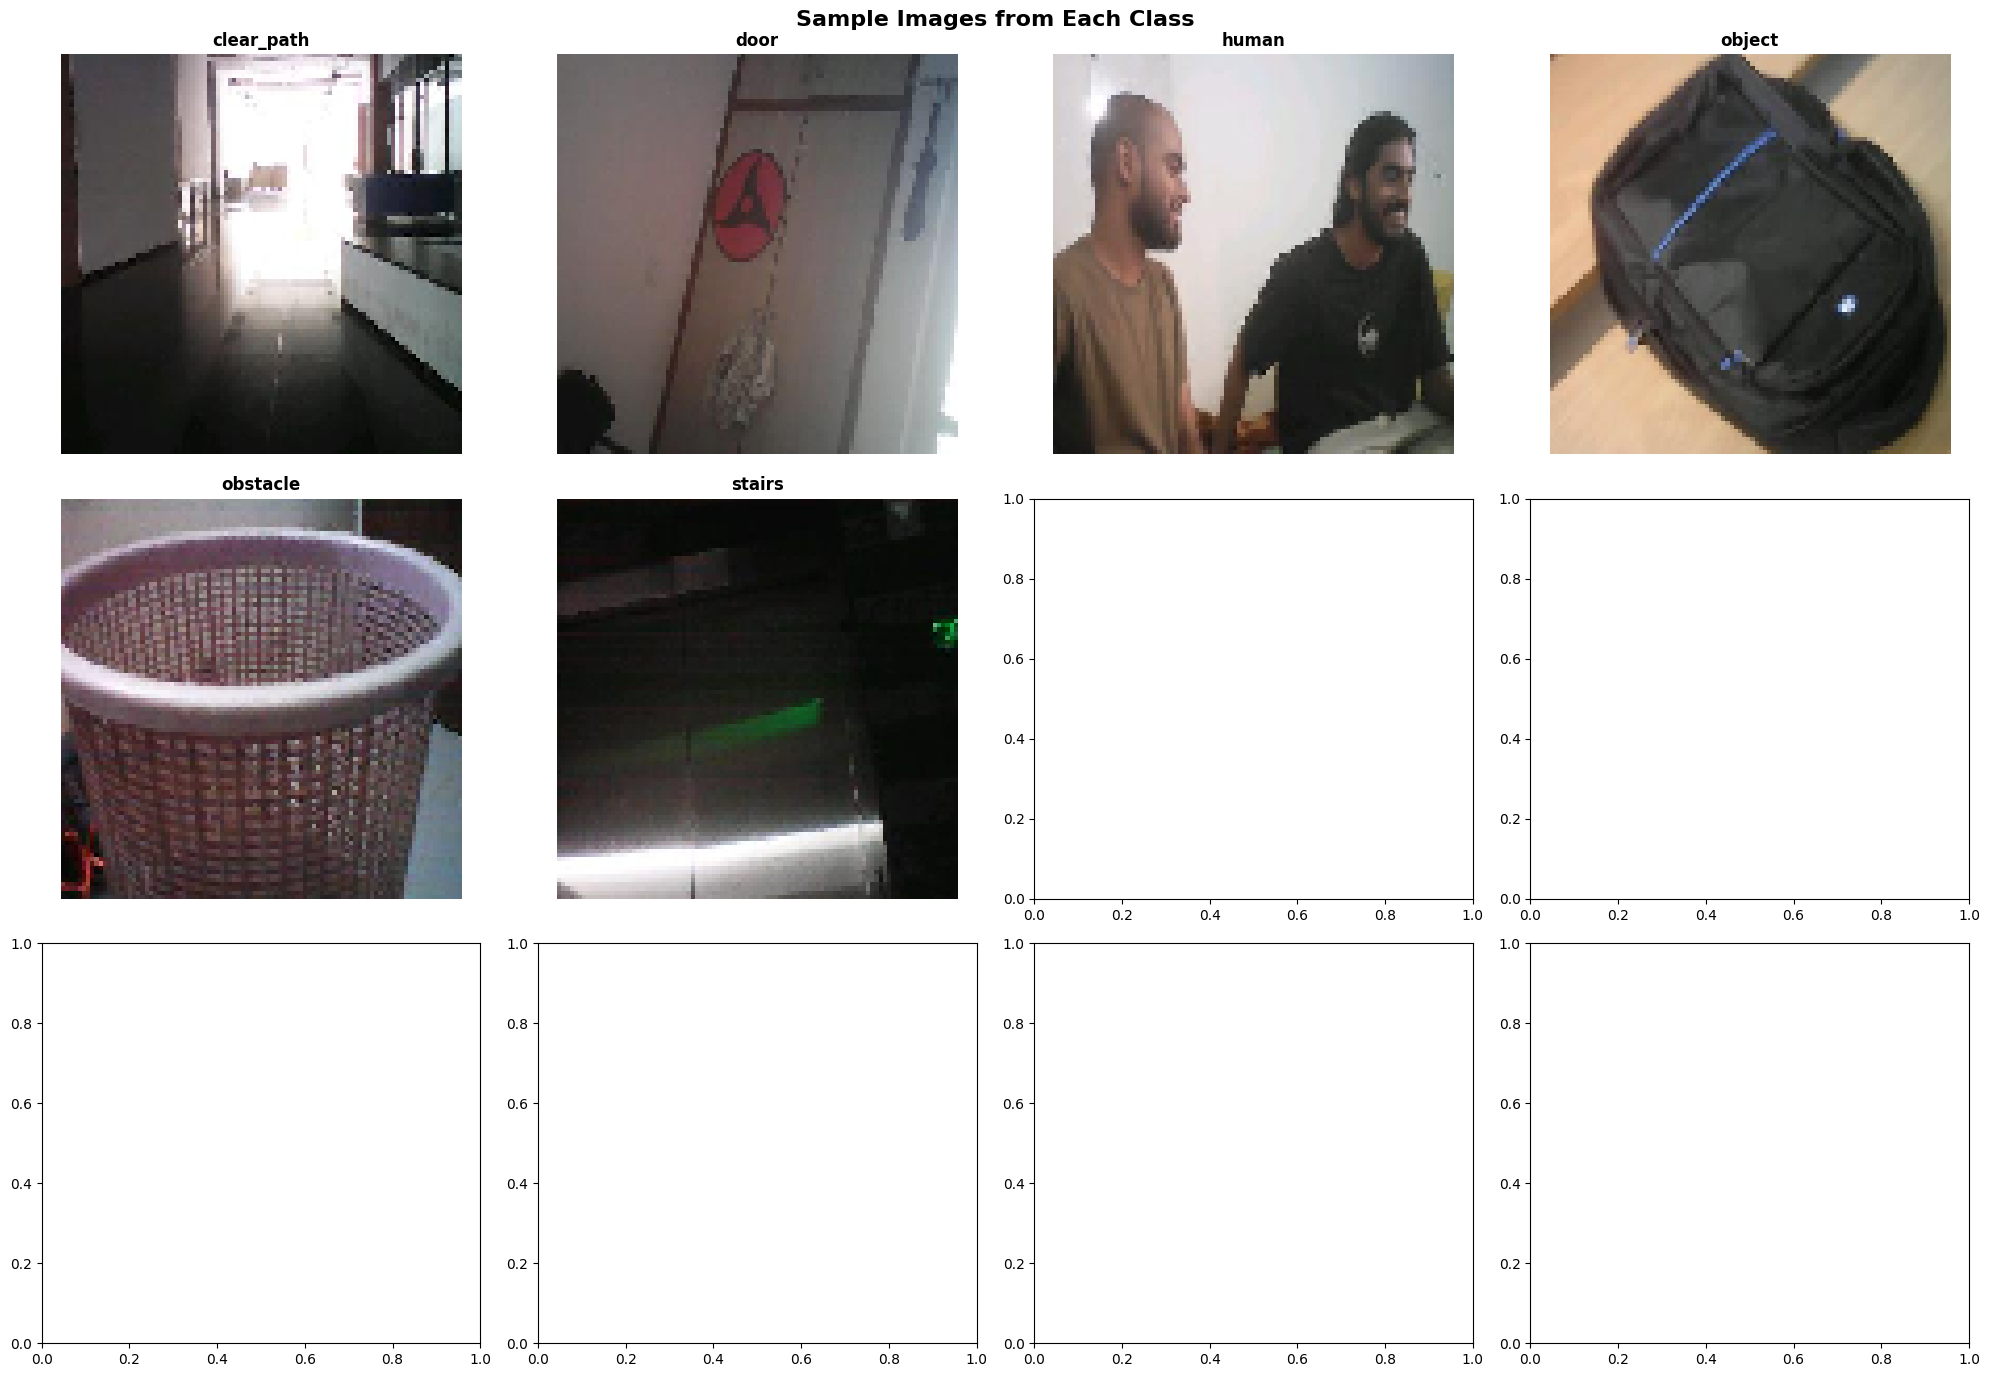

Sample images saved!


In [10]:
# Visualize sample images from each class
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for idx, cls in enumerate(class_names):
    ax = axes[idx // 4, idx % 4]
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)
    if images:
        img = tf.keras.utils.load_img(
            os.path.join(cls_path, images[0]),
            target_size=(IMG_SIZE, IMG_SIZE)
        )
        ax.imshow(img)
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'sample_images.png'), dpi=150)
plt.show()
print("Sample images saved!")

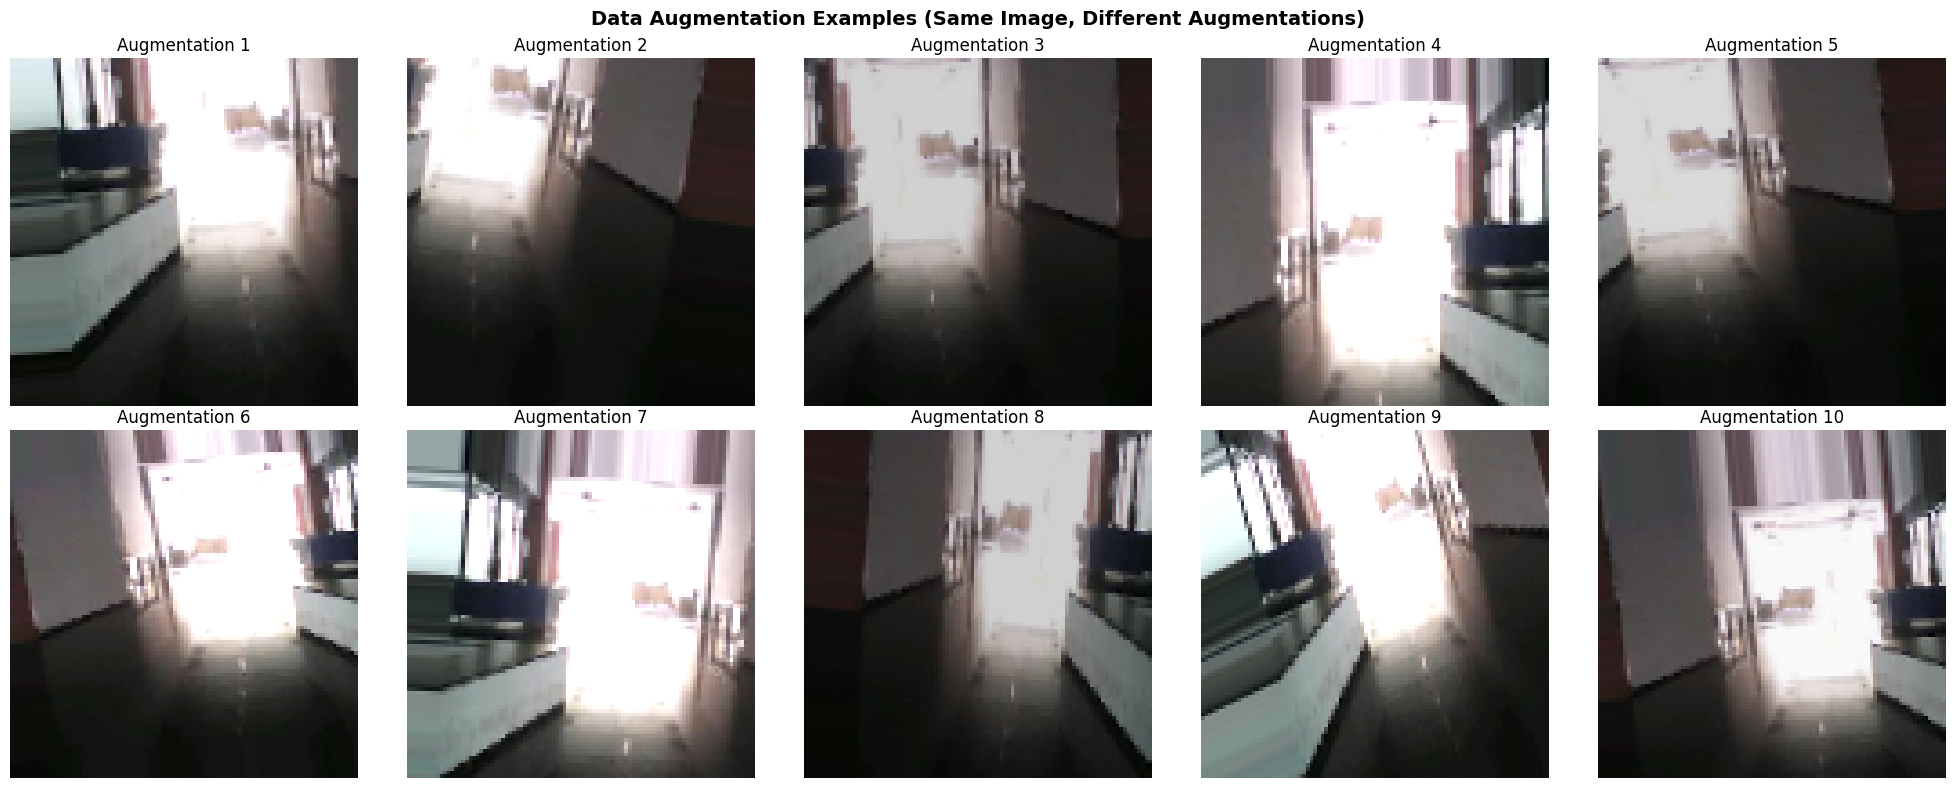

In [11]:
# Visualize data augmentation effects
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Data Augmentation Examples (Same Image, Different Augmentations)',
             fontsize=14, fontweight='bold')

# Get one sample image
sample_cls = class_names[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls)
sample_img_name = os.listdir(sample_path)[0]
sample_img = tf.keras.utils.load_img(
    os.path.join(sample_path, sample_img_name),
    target_size=(IMG_SIZE, IMG_SIZE)
)
sample_arr = tf.keras.utils.img_to_array(sample_img)
sample_arr = sample_arr.reshape((1,) + sample_arr.shape)

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.15,
    zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)

aug_iter = aug_gen.flow(sample_arr, batch_size=1)
for i in range(10):
    ax = axes[i // 5, i % 5]
    aug_img = next(aug_iter)[0].astype('uint8')
    ax.imshow(aug_img)
    ax.set_title(f'Augmentation {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'augmentation_examples.png'), dpi=150)
plt.show()

In [12]:
# Load ALL data into numpy arrays (needed for Knowledge Distillation later)
# This gives us full control over the training loop

def load_dataset_to_numpy(directory, img_size):
    """Load all images from class-organized directory into numpy arrays."""
    images = []
    labels = []
    classes = sorted(os.listdir(directory))
    classes = [c for c in classes if os.path.isdir(os.path.join(directory, c))]

    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(directory, class_name)
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                img_path = os.path.join(class_dir, img_name)
                try:
                    img = tf.keras.utils.load_img(img_path, target_size=(img_size, img_size))
                    img_arr = tf.keras.utils.img_to_array(img) / 255.0
                    images.append(img_arr)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"  Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

print("Loading training data to numpy arrays...")
X_train_full, y_train_full = load_dataset_to_numpy(TRAIN_DIR, IMG_SIZE)
print("Loading test data to numpy arrays...")
X_test, y_test = load_dataset_to_numpy(TEST_DIR, IMG_SIZE)

# Split train into train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full
)

# One-hot encode
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_oh = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"\nDataset shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Loading training data to numpy arrays...
Loading test data to numpy arrays...

Dataset shapes:
  X_train: (2996, 96, 96, 3), y_train: (2996,)
  X_val:   (529, 96, 96, 3),   y_val:   (529,)
  X_test:  (626, 96, 96, 3),  y_test:  (626,)


---
## Section 3: Baseline — Decision Tree Classifier (Lab 04)

Before diving into deep learning, we establish a **non-neural-network baseline** using a Decision Tree.
This mirrors the approach from Lab 04 and provides a reference point for our CNN models.

In [13]:
# ============================================================================
# SECTION 3: BASELINE — DECISION TREE CLASSIFIER (Lab 04)
# ============================================================================

# Flatten images into feature vectors for Decision Tree
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened feature vector size: {X_train_flat.shape[1]} features")
print(f"  (This is {IMG_SIZE} x {IMG_SIZE} x 3 = {IMG_SIZE*IMG_SIZE*3})")

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=15,
    random_state=SEED
)

print("\nTraining Decision Tree...")
start_time = time.time()
dt_model.fit(X_train_flat, y_train)
dt_train_time = time.time() - start_time
print(f"Training time: {dt_train_time:.2f}s")

# Evaluate
dt_train_pred = dt_model.predict(X_train_flat)
dt_test_pred = dt_model.predict(X_test_flat)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

print(f"\nDecision Tree Results:")
print(f"  Training Accuracy: {dt_train_acc*100:.2f}%")
print(f"  Test Accuracy:     {dt_test_acc*100:.2f}%")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, dt_test_pred,
                            target_names=class_names, digits=3))

Flattened feature vector size: 27648 features
  (This is 96 x 96 x 3 = 27648)

Training Decision Tree...
Training time: 98.77s

Decision Tree Results:
  Training Accuracy: 100.00%
  Test Accuracy:     76.68%

Classification Report (Test Set):
              precision    recall  f1-score   support

  clear_path      0.725     0.704     0.714        71
        door      0.892     0.874     0.883        95
       human      0.712     0.743     0.727        70
      object      0.710     0.710     0.710       176
    obstacle      0.750     0.672     0.709       116
      stairs      0.829     0.939     0.880        98

    accuracy                          0.767       626
   macro avg      0.770     0.774     0.771       626
weighted avg      0.766     0.767     0.765       626



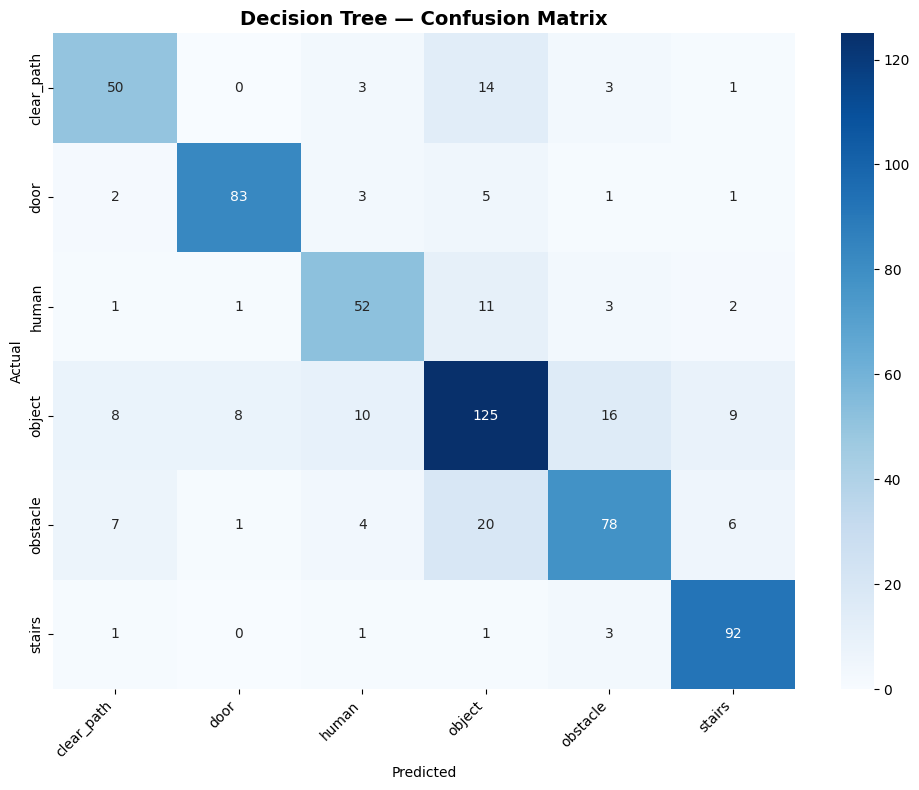

In [14]:
# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'dt_confusion_matrix.png'), dpi=150)
plt.show()

---
## Section 4: Custom CNN Model — From Scratch (Lab 05 — ANN and CNN)

We build a lightweight CNN specifically designed for edge deployment.
The architecture uses:
- 3 Conv2D blocks with BatchNormalization and MaxPooling
- GlobalAveragePooling2D (much more memory-efficient than Flatten)
- Dropout for regularization

In [15]:
# ===========================================================================
# CELL: CUSTOM CNN — LARGER ARCHITECTURE (Replace Section 4 build cell)
# Must produce TFLite Float32 > 300KB to justify compression
# ===========================================================================
def build_custom_cnn(input_shape, num_classes):
    """Big CNN with Flatten — matches Edge Impulse style but larger.
    This model is TOO BIG for Nicla Vision (>300KB), justifying compression.
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D(2, 2, name='pool1'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'),
        layers.MaxPooling2D(2, 2, name='pool2'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv3'),
        layers.MaxPooling2D(2, 2, name='pool3'),
        layers.Flatten(name='flatten'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='custom_cnn')
    return model

model_cnn = build_custom_cnn(IMG_SHAPE, NUM_CLASSES)
model_cnn.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "custom_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 96, 96, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 48, 48, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 48, 48, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 24, 24, 64)        0         
                                                                 
 conv3 (Conv2D)              (None, 24, 24, 64)        36928     
                                                                 
 pool3 (MaxPooling2D)        (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0

In [16]:
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    )
]

print("Training Custom CNN...")
print("=" * 50)

start_time = time.time()
history_cnn = model_cnn.fit(
    X_train, y_train_oh,
    epochs=EPOCHS_CNN,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_oh),
    callbacks=cnn_callbacks,
    verbose=1
)
cnn_train_time = time.time() - start_time
print(f"\nTraining completed in {cnn_train_time:.1f}s")

Training Custom CNN...
Epoch 1/30
94/94 [==============================] - 9s 22ms/step - loss: 1.2164 - accuracy: 0.5454 - val_loss: 0.8107 - val_accuracy: 0.7183 - lr: 0.0010
Epoch 2/30
94/94 [==============================] - 1s 14ms/step - loss: 0.5586 - accuracy: 0.8241 - val_loss: 0.4840 - val_accuracy: 0.8261 - lr: 0.0010
Epoch 3/30
94/94 [==============================] - 1s 13ms/step - loss: 0.3174 - accuracy: 0.9035 - val_loss: 0.3611 - val_accuracy: 0.8828 - lr: 0.0010
Epoch 4/30
94/94 [==============================] - 1s 12ms/step - loss: 0.2348 - accuracy: 0.9329 - val_loss: 0.2477 - val_accuracy: 0.9301 - lr: 0.0010
Epoch 5/30
94/94 [==============================] - 1s 11ms/step - loss: 0.1440 - accuracy: 0.9553 - val_loss: 0.3234 - val_accuracy: 0.9055 - lr: 0.0010
Epoch 6/30
94/94 [==============================] - 1s 11ms/step - loss: 0.1365 - accuracy: 0.9599 - val_loss: 0.3743 - val_accuracy: 0.8828 - lr: 0.0010
Epoch 7/30
94/94 [==============================] - 1

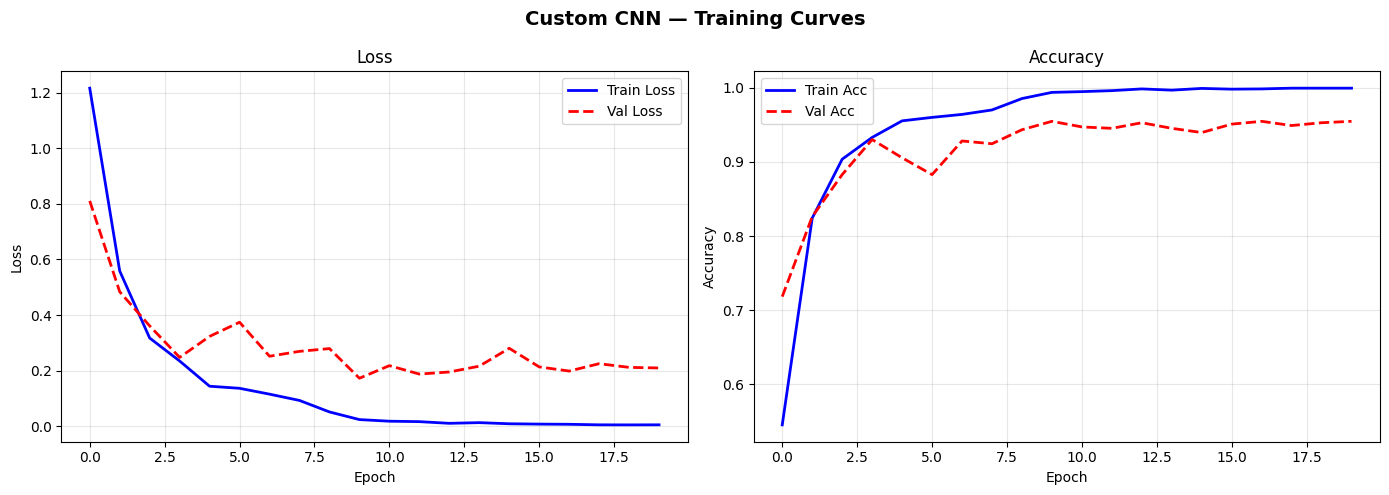

In [17]:
# Plot CNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training Curves', fontsize=14, fontweight='bold')

# Loss
ax1.plot(history_cnn.history['loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(history_cnn.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history_cnn.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(history_cnn.history['val_accuracy'], 'r--', label='Val Acc', linewidth=2)
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cnn_training_curves.png'), dpi=150)
plt.show()

20/20 [==============================] - 0s 5ms/step
Custom CNN Test Accuracy: 95.69%
Custom CNN Test Loss:     0.1599

Classification Report:
              precision    recall  f1-score   support

  clear_path      0.972     0.972     0.972        71
        door      0.959     0.989     0.974        95
       human      0.985     0.943     0.964        70
      object      0.937     0.932     0.934       176
    obstacle      0.940     0.948     0.944       116
      stairs      0.980     0.980     0.980        98

    accuracy                          0.957       626
   macro avg      0.962     0.961     0.961       626
weighted avg      0.957     0.957     0.957       626



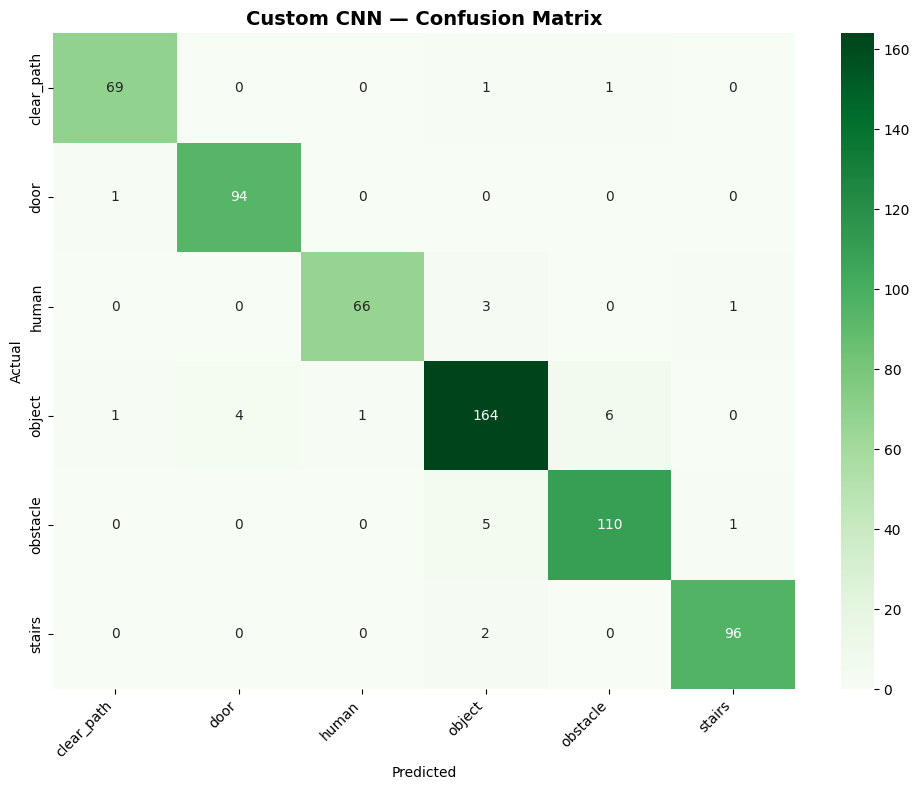

In [18]:
# Evaluate Custom CNN
cnn_loss, cnn_acc = model_cnn.evaluate(X_test, y_test_oh, verbose=0)

y_pred_cnn = model_cnn.predict(X_test)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

print(f"Custom CNN Test Accuracy: {cnn_acc*100:.2f}%")
print(f"Custom CNN Test Loss:     {cnn_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_cnn_classes,
                            target_names=class_names, digits=3))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cnn_confusion_matrix.png'), dpi=150)
plt.show()

---
## Section 5: Teacher Model — MobileNetV2 Transfer Learning (Lab 05)

We use **MobileNetV2** pretrained on ImageNet as a powerful **teacher model**.
Transfer learning lets us leverage features learned from millions of images.
This teacher will later be used to train a smaller student via Knowledge Distillation.

In [19]:
# ============================================================================
# SECTION 5: TEACHER MODEL — MobileNetV2 TRANSFER LEARNING (Lab 05)
# ============================================================================

def build_teacher_model(input_shape, num_classes):
    """Build MobileNetV2-based teacher model with transfer learning."""
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model layers initially
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='teacher_mobilenetv2')

    return model, base_model

teacher_model, teacher_base = build_teacher_model(IMG_SHAPE, NUM_CLASSES)

teacher_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

teacher_model.summary()
print(f"\nTotal parameters: {teacher_model.count_params():,}")
print(f"Trainable parameters: {sum(tf.keras.backend.count_params(w) for w in teacher_model.trainable_weights):,}")

9406464/9406464 [==============================] - 0s 0us/step
Model: "teacher_mobilenetv2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_96 (Funct  (None, 3, 3, 1280)        2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 6)                 774       
                                                  

In [20]:
# STAGE 1: Train with frozen base (feature extraction)
print("Stage 1: Training with frozen MobileNetV2 base...")
print("=" * 50)

teacher_callbacks_s1 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_teacher_s1 = teacher_model.fit(
    X_train, y_train_oh,
    epochs=15,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_oh),
    callbacks=teacher_callbacks_s1,
    verbose=1
)

Stage 1: Training with frozen MobileNetV2 base...
Epoch 1/15
94/94 [==============================] - 7s 32ms/step - loss: 0.3656 - accuracy: 0.8738 - val_loss: 0.0774 - val_accuracy: 0.9735 - lr: 0.0010
Epoch 2/15
94/94 [==============================] - 1s 16ms/step - loss: 0.0561 - accuracy: 0.9860 - val_loss: 0.0581 - val_accuracy: 0.9849 - lr: 0.0010
Epoch 3/15
94/94 [==============================] - 2s 18ms/step - loss: 0.0270 - accuracy: 0.9933 - val_loss: 0.0461 - val_accuracy: 0.9849 - lr: 0.0010
Epoch 4/15
94/94 [==============================] - 2s 19ms/step - loss: 0.0161 - accuracy: 0.9963 - val_loss: 0.0369 - val_accuracy: 0.9887 - lr: 0.0010
Epoch 5/15
94/94 [==============================] - 2s 17ms/step - loss: 0.0120 - accuracy: 0.9980 - val_loss: 0.0337 - val_accuracy: 0.9887 - lr: 0.0010
Epoch 6/15
94/94 [==============================] - 1s 15ms/step - loss: 0.0079 - accuracy: 0.9987 - val_loss: 0.0231 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 7/15
94/94 [========

In [21]:
# STAGE 2: Unfreeze last 30 layers and fine-tune
print("\nStage 2: Fine-tuning last 30 layers of MobileNetV2...")
print("=" * 50)

teacher_base.trainable = True
for layer in teacher_base.layers[:-30]:
    layer.trainable = False

# Use lower learning rate for fine-tuning
teacher_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

teacher_callbacks_s2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_teacher_s2 = teacher_model.fit(
    X_train, y_train_oh,
    epochs=EPOCHS_TEACHER,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_oh),
    callbacks=teacher_callbacks_s2,
    verbose=1
)


Stage 2: Fine-tuning last 30 layers of MobileNetV2...
Epoch 1/25
94/94 [==============================] - 12s 35ms/step - loss: 0.0857 - accuracy: 0.9696 - val_loss: 0.0290 - val_accuracy: 0.9887 - lr: 1.0000e-04
Epoch 2/25
94/94 [==============================] - 2s 20ms/step - loss: 0.0186 - accuracy: 0.9940 - val_loss: 0.0428 - val_accuracy: 0.9830 - lr: 1.0000e-04
Epoch 3/25
94/94 [==============================] - 2s 20ms/step - loss: 0.0146 - accuracy: 0.9963 - val_loss: 0.0460 - val_accuracy: 0.9849 - lr: 1.0000e-04
Epoch 4/25
94/94 [==============================] - ETA: 0s - loss: 0.0067 - accuracy: 0.9977
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/94 [==============================] - 2s 20ms/step - loss: 0.0067 - accuracy: 0.9977 - val_loss: 0.0359 - val_accuracy: 0.9924 - lr: 1.0000e-04
Epoch 5/25
94/94 [==============================] - 2s 25ms/step - loss: 0.0077 - accuracy: 0.9980 - val_loss: 0.0212 - val_accuracy: 0.9943 - lr: 5.0000

20/20 [==============================] - 1s 9ms/step
Teacher (MobileNetV2) Test Accuracy: 99.20%
Teacher Test Loss: 0.0414

Classification Report:
              precision    recall  f1-score   support

  clear_path      0.986     1.000     0.993        71
        door      0.979     1.000     0.990        95
       human      1.000     0.986     0.993        70
      object      0.994     0.989     0.991       176
    obstacle      1.000     0.983     0.991       116
      stairs      0.990     1.000     0.995        98

    accuracy                          0.992       626
   macro avg      0.992     0.993     0.992       626
weighted avg      0.992     0.992     0.992       626



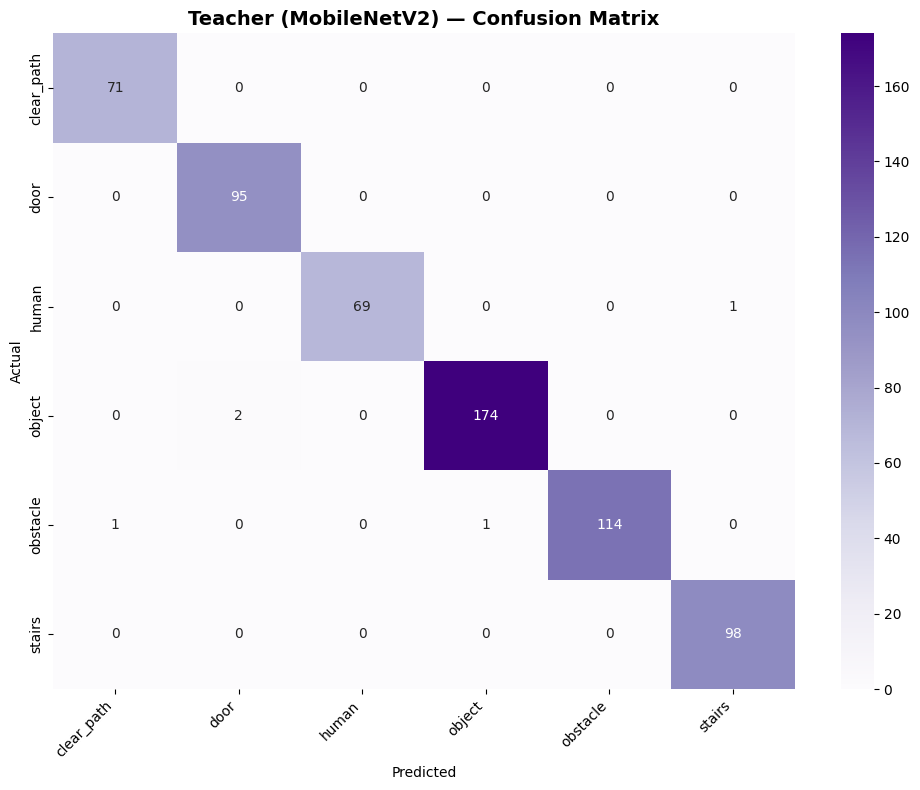

In [22]:
# Evaluate Teacher Model
teacher_loss, teacher_acc = teacher_model.evaluate(X_test, y_test_oh, verbose=0)

y_pred_teacher = teacher_model.predict(X_test)
y_pred_teacher_classes = np.argmax(y_pred_teacher, axis=1)

print(f"Teacher (MobileNetV2) Test Accuracy: {teacher_acc*100:.2f}%")
print(f"Teacher Test Loss: {teacher_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_teacher_classes,
                            target_names=class_names, digits=3))

# Confusion Matrix
cm_teacher = confusion_matrix(y_test, y_pred_teacher_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_teacher, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Teacher (MobileNetV2) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'teacher_confusion_matrix.png'), dpi=150)
plt.show()

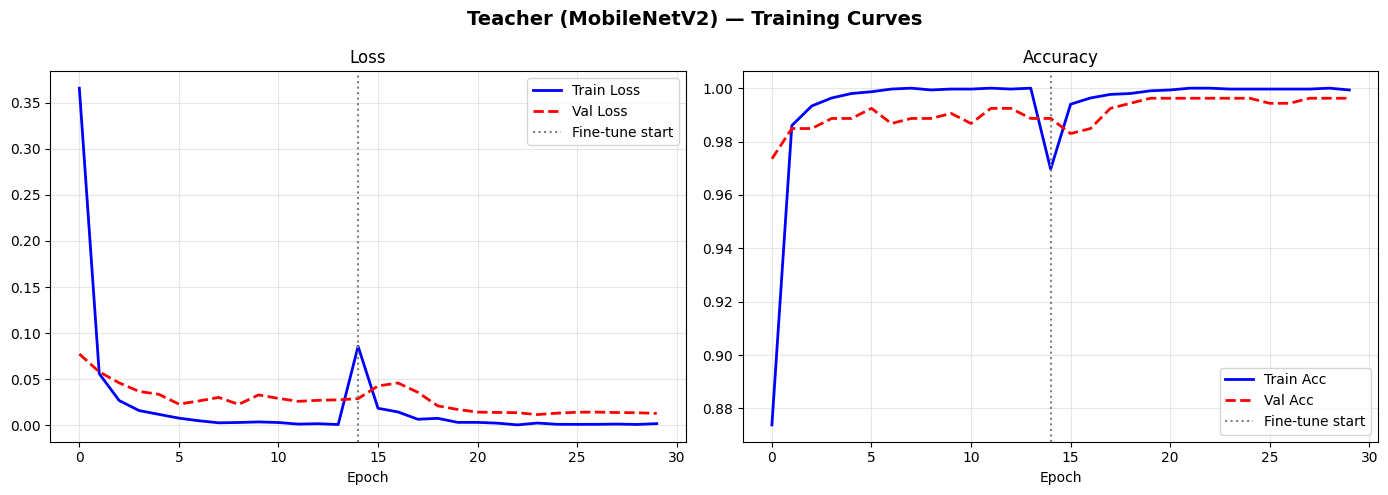

In [23]:
# Plot Teacher training curves (both stages)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Teacher (MobileNetV2) — Training Curves', fontsize=14, fontweight='bold')

# Combine both stages
teacher_acc_hist = history_teacher_s1.history['accuracy'] + history_teacher_s2.history['accuracy']
teacher_val_acc_hist = history_teacher_s1.history['val_accuracy'] + history_teacher_s2.history['val_accuracy']
teacher_loss_hist = history_teacher_s1.history['loss'] + history_teacher_s2.history['loss']
teacher_val_loss_hist = history_teacher_s1.history['val_loss'] + history_teacher_s2.history['val_loss']

s1_epochs = len(history_teacher_s1.history['loss'])

ax1.plot(teacher_loss_hist, 'b-', label='Train Loss', linewidth=2)
ax1.plot(teacher_val_loss_hist, 'r--', label='Val Loss', linewidth=2)
ax1.axvline(x=s1_epochs, color='gray', linestyle=':', label='Fine-tune start')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(teacher_acc_hist, 'b-', label='Train Acc', linewidth=2)
ax2.plot(teacher_val_acc_hist, 'r--', label='Val Acc', linewidth=2)
ax2.axvline(x=s1_epochs, color='gray', linestyle=':', label='Fine-tune start')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'teacher_training_curves.png'), dpi=150)
plt.show()

---
## Section 6: Model Parameters & Efficiency Metrics (Lab 06)

We analyze and compare models using:
- Total parameter count
- Model size (MB)
- FLOPs (Floating Point Operations)
- MACs (Multiply-Accumulate Operations)
- Layer-wise breakdown

In [24]:
# ============================================================================
# SECTION 6: MODEL PARAMETERS & EFFICIENCY METRICS (Lab 06)
# ============================================================================

def analyze_model(model, name):
    """Compute efficiency metrics for a Keras model."""
    total_params = model.count_params()
    model_size_mb = total_params * np.float32().nbytes / (1024**2)

    # Compute FLOPs and MACs
    total_flops = 0
    total_macs = 0

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            output_shape = layer.output.shape
            kernel_ops = np.prod(layer.kernel_size) * layer.input.shape[-1]
            output_elements = np.prod(output_shape[1:])
            macs = int(kernel_ops * output_elements)
            flops = 2 * macs
            total_macs += macs
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.Dense):
            macs = int(layer.input.shape[-1] * layer.output.shape[-1])
            flops = 2 * macs
            total_macs += macs
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.DepthwiseConv2D):
            output_shape = layer.output.shape
            kernel_ops = np.prod(layer.kernel_size)
            output_elements = np.prod(output_shape[1:])
            macs = int(kernel_ops * output_elements)
            flops = 2 * macs
            total_macs += macs
            total_flops += flops

    # Peak memory (activations)
    peak_activations = 0
    total_activations = 0
    for layer in model.layers:
        if hasattr(layer, 'output_shape'):
            out_shape = layer.output_shape
            if isinstance(out_shape, list):
                out_shape = out_shape[0]
            act = np.prod([s for s in out_shape[1:] if s is not None])
            total_activations += act
            peak_activations = max(peak_activations, act)

    return {
        'name': name,
        'params': total_params,
        'size_mb': model_size_mb,
        'flops': total_flops,
        'macs': total_macs,
        'peak_act': peak_activations,
        'total_act': total_activations
    }

# Analyze models
metrics_cnn = analyze_model(model_cnn, 'Custom CNN')
metrics_teacher = analyze_model(teacher_model, 'MobileNetV2 Teacher')

# Print comparison table
print("=" * 70)
print(f"{'METRIC':<30} {'CUSTOM CNN':>18} {'MOBILENETV2':>18}")
print("=" * 70)
print(f"{'Parameters':<30} {metrics_cnn['params']:>18,} {metrics_teacher['params']:>18,}")
print(f"{'Model Size (MB)':<30} {metrics_cnn['size_mb']:>18.2f} {metrics_teacher['size_mb']:>18.2f}")
print(f"{'FLOPs':<30} {metrics_cnn['flops']:>18,} {metrics_teacher['flops']:>18,}")
print(f"{'MACs':<30} {metrics_cnn['macs']:>18,} {metrics_teacher['macs']:>18,}")
print(f"{'Peak Activations':<30} {metrics_cnn['peak_act']:>18,} {metrics_teacher['peak_act']:>18,}")
print(f"{'Test Accuracy':<30} {cnn_acc*100:>17.2f}% {teacher_acc*100:>17.2f}%")
print("=" * 70)

METRIC                                 CUSTOM CNN        MOBILENETV2
Parameters                                111,622          2,422,726
Model Size (MB)                              0.43               9.24
FLOPs                                 143,437,824            329,216
MACs                                   71,718,912            164,608
Peak Activations                          294,912             11,520
Test Accuracy                              95.69%             99.20%


In [25]:
# Layer-wise parameter analysis for Custom CNN
print("\nCustom CNN — Layer-wise Analysis")
print("=" * 55)
for layer in model_cnn.layers:
    params = layer.count_params()
    if params > 0:
        print(f"  {layer.name:20s}: {params:>10,} params")
print(f"  {'TOTAL':20s}: {model_cnn.count_params():>10,} params")


Custom CNN — Layer-wise Analysis
  conv1               :        896 params
  conv2               :     18,496 params
  conv3               :     36,928 params
  output              :     55,302 params
  TOTAL               :    111,622 params


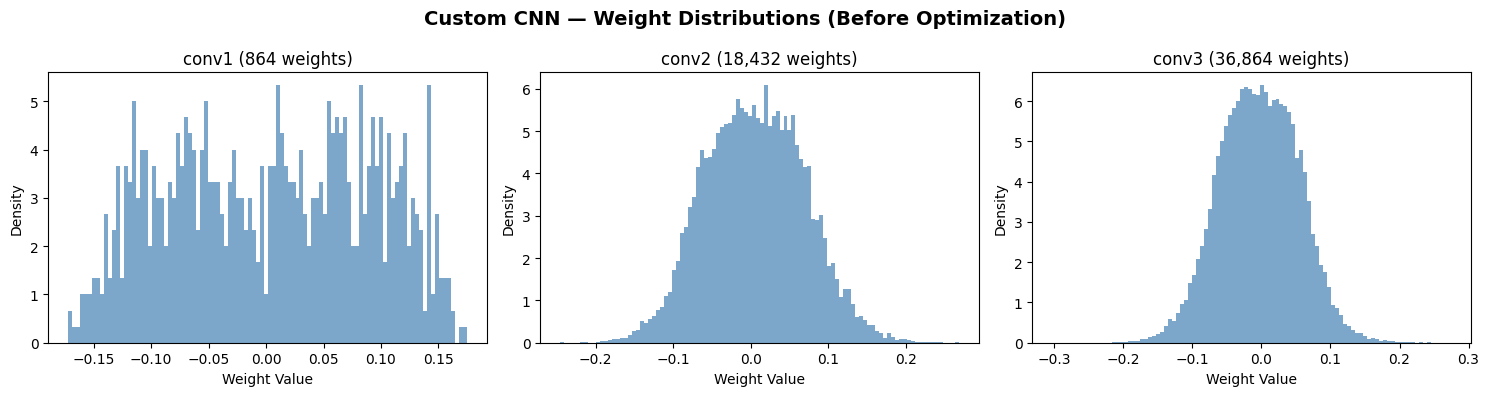

In [26]:
# Visualize weight distributions of Custom CNN (before any optimization)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Custom CNN — Weight Distributions (Before Optimization)',
             fontsize=14, fontweight='bold')

conv_layers = [l for l in model_cnn.layers if isinstance(l, tf.keras.layers.Conv2D)]
for ax, layer in zip(axes, conv_layers):
    weights = layer.kernel.numpy().flatten()
    ax.hist(weights, bins=100, density=True, color='steelblue', alpha=0.7)
    ax.set_title(f'{layer.name} ({weights.size:,} weights)')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cnn_weight_distributions.png'), dpi=150)
plt.show()

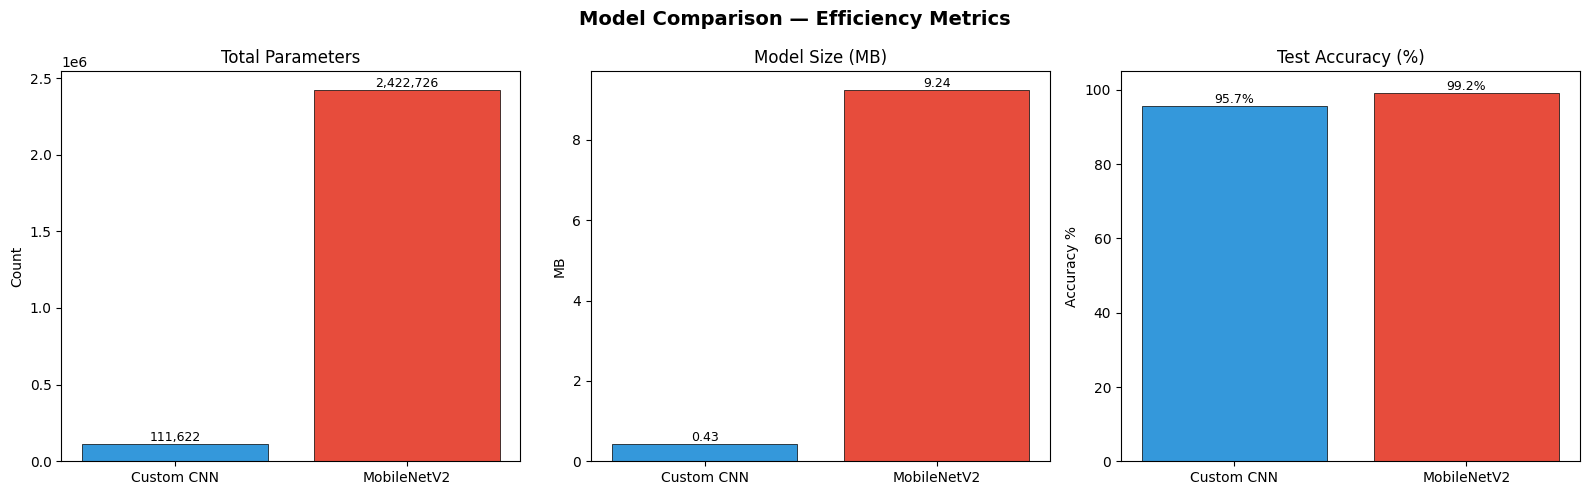

In [27]:
# Parameter comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Efficiency Metrics', fontsize=14, fontweight='bold')
colors = ['#3498db', '#e74c3c']
model_names = ['Custom CNN', 'MobileNetV2']

# Parameters
axes[0].bar(model_names, [metrics_cnn['params'], metrics_teacher['params']],
            color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Total Parameters')
axes[0].set_ylabel('Count')
for i, v in enumerate([metrics_cnn['params'], metrics_teacher['params']]):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

# Model Size
axes[1].bar(model_names, [metrics_cnn['size_mb'], metrics_teacher['size_mb']],
            color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Model Size (MB)')
axes[1].set_ylabel('MB')
for i, v in enumerate([metrics_cnn['size_mb'], metrics_teacher['size_mb']]):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Accuracy
axes[2].bar(model_names, [cnn_acc*100, teacher_acc*100],
            color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('Test Accuracy (%)')
axes[2].set_ylabel('Accuracy %')
axes[2].set_ylim(0, 105)
for i, v in enumerate([cnn_acc*100, teacher_acc*100]):
    axes[2].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'model_comparison_metrics.png'), dpi=150)
plt.show()

---
## Section 7: Knowledge Distillation — Student Model (Lab 10)

**Knowledge Distillation** transfers the "dark knowledge" from the large teacher (MobileNetV2)
to a tiny student model. The student learns from:
1. **Soft targets** — Teacher's probability distributions (softened with temperature)
2. **Hard targets** — Ground truth labels

**Distillation Loss:** L = α · KL(soft_student, soft_teacher) · T² + (1-α) · CE(student, hard_labels)

The student uses **Depthwise Separable Convolutions** (like MobileNet) for extreme efficiency,
targeting <100K parameters to fit on Arduino Nicla Vision.

In [28]:
# ============================================================================
# SECTION 7: KNOWLEDGE DISTILLATION (Lab 10)
# ============================================================================

def build_student_model(input_shape, num_classes):
    """Student matching Edge Impulse's proven architecture.
    Conv2D(16)→Pool→Conv2D(32)→Pool→Flatten→Dropout→Dense
    Uses Flatten (NOT GAP) — this is key for accuracy!
    """
    model = models.Sequential([
        layers.Conv2D(16, (3, 3), padding='same', activation='relu',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D(2, 2, name='pool1'),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2'),
        layers.MaxPooling2D(2, 2, name='pool2'),
        layers.Flatten(name='flatten'),
        layers.Dropout(0.25, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='student_model')
    return model

student_model = build_student_model(IMG_SHAPE, NUM_CLASSES)
student_model.summary()
print(f"\nStudent parameters: {student_model.count_params():,}")
print(f"Estimated Float32 TFLite: ~{student_model.count_params()*4/1024:.0f} KB")

Model: "student_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 96, 96, 16)        448       
                                                                 
 pool1 (MaxPooling2D)        (None, 48, 48, 16)        0         
                                                                 
 conv2 (Conv2D)              (None, 48, 48, 32)        4640      
                                                                 
 pool2 (MaxPooling2D)        (None, 24, 24, 32)        0         
                                                                 
 flatten (Flatten)           (None, 18432)             0         
                                                                 
 dropout (Dropout)           (None, 18432)             0         
                                                                 
 output (Dense)              (None, 6)               

In [29]:
# --- STEP 1: Train a Vanilla Student (without KD) as baseline ---

vanilla_student = build_student_model(IMG_SHAPE, NUM_CLASSES)
vanilla_student.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("Training Vanilla Student (NO Knowledge Distillation)...")
print("=" * 50)

vanilla_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history_vanilla = vanilla_student.fit(
    X_train, y_train_oh,
    epochs=EPOCHS_KD,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_oh),
    callbacks=vanilla_callbacks,
    verbose=1
)

vanilla_loss, vanilla_acc = vanilla_student.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nVanilla Student Test Accuracy: {vanilla_acc*100:.2f}%")

Training Vanilla Student (NO Knowledge Distillation)...
Epoch 1/30
94/94 [==============================] - 3s 13ms/step - loss: 1.2396 - accuracy: 0.6055 - val_loss: 0.9569 - val_accuracy: 0.7845 - lr: 0.0010
Epoch 2/30
94/94 [==============================] - 1s 7ms/step - loss: 0.8124 - accuracy: 0.8551 - val_loss: 0.7772 - val_accuracy: 0.8922 - lr: 0.0010
Epoch 3/30
94/94 [==============================] - 1s 7ms/step - loss: 0.6836 - accuracy: 0.9142 - val_loss: 0.7306 - val_accuracy: 0.9055 - lr: 0.0010
Epoch 4/30
94/94 [==============================] - 1s 7ms/step - loss: 0.6196 - accuracy: 0.9529 - val_loss: 0.7020 - val_accuracy: 0.9149 - lr: 0.0010
Epoch 5/30
94/94 [==============================] - 1s 7ms/step - loss: 0.5777 - accuracy: 0.9670 - val_loss: 0.6579 - val_accuracy: 0.9168 - lr: 0.0010
Epoch 6/30
94/94 [==============================] - 1s 7ms/step - loss: 0.5468 - accuracy: 0.9786 - val_loss: 0.6760 - val_accuracy: 0.9149 - lr: 0.0010
Epoch 7/30
94/94 [=======

In [30]:
# --- STEP 2: Generate Soft Targets from Teacher ---

print("Generating soft targets from teacher model...")
print("(Running teacher once on all training data — done offline for efficiency)")

# Get teacher predictions on training data
teacher_preds_train = teacher_model.predict(X_train, verbose=1)
teacher_preds_val = teacher_model.predict(X_val, verbose=1)

print(f"Teacher predictions shape: {teacher_preds_train.shape}")
print(f"Sample teacher prediction: {teacher_preds_train[0]}")
print(f"Sum of probabilities: {teacher_preds_train[0].sum():.6f}")

Generating soft targets from teacher model...
(Running teacher once on all training data — done offline for efficiency)
17/17 [==============================] - 0s 10ms/step
Teacher predictions shape: (2996, 6)
Sample teacher prediction: [5.0981819e-10 2.1056320e-11 2.4502156e-10 1.8591091e-09 1.0000000e+00
 3.8490748e-09]
Sum of probabilities: 1.000000


In [31]:
# --- STEP 3: Temperature Scaling ---

def apply_temperature(probs, temperature):
    """Apply temperature scaling to soften probability distributions.

    Steps:
      1. Convert probabilities → logits: z = log(p)
      2. Scale logits: z_T = z / T
      3. Re-normalize with softmax: p_T = softmax(z_T)

    Higher T → softer distribution → more "dark knowledge" transferred
    """
    logits = np.log(probs + 1e-10)  # Avoid log(0)
    scaled_logits = logits / temperature
    # Numerically stable softmax
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

# Generate soft targets with temperature scaling
soft_targets_train = apply_temperature(teacher_preds_train, TEMPERATURE)
soft_targets_val = apply_temperature(teacher_preds_val, TEMPERATURE)

print(f"Temperature: {TEMPERATURE}")
print(f"\nOriginal teacher prediction (T=1):")
print(f"  {teacher_preds_train[0]}")
print(f"\nSoft target (T={TEMPERATURE}):")
print(f"  {soft_targets_train[0]}")
print(f"\nNotice how the distribution is now softer (more uniform)")

Temperature: 3.0

Original teacher prediction (T=1):
  [5.0981819e-10 2.1056320e-11 2.4502156e-10 1.8591091e-09 1.0000000e+00
 3.8490748e-09]

Soft target (T=3.0):
  [8.4389327e-04 4.9228535e-04 6.9796905e-04 1.2452040e-03 9.9514776e-01
 1.5729659e-03]

Notice how the distribution is now softer (more uniform)


In [32]:
# --- STEP 4: Build and Train KD Student with Custom Training Loop ---

kd_student = build_student_model(IMG_SHAPE, NUM_CLASSES)
kd_student.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("KD Student Architecture (identical to vanilla student):")
print(f"  Parameters: {kd_student.count_params():,}")

epochs = EPOCHS_KD
batch_size = BATCH_SIZE
steps_per_epoch = len(X_train) // batch_size

print(f"\nTraining for {epochs} epochs")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Alpha (distillation weight): {ALPHA}")
print(f"Temperature: {TEMPERATURE}")

KD Student Architecture (identical to vanilla student):
  Parameters: 115,686

Training for 30 epochs
Steps per epoch: 93
Alpha (distillation weight): 0.5
Temperature: 3.0


In [33]:
# --- Generate soft targets ---
print("Generating soft targets from teacher model...")
teacher_preds_train = teacher_model.predict(X_train, verbose=1)
teacher_preds_val = teacher_model.predict(X_val, verbose=1)

soft_targets_train = apply_temperature(teacher_preds_train, TEMPERATURE)
soft_targets_val = apply_temperature(teacher_preds_val, TEMPERATURE)

# --- Custom KD training loop ---
kd_history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * epochs,
    alpha=1e-5  # minimum LR
)
optimizer = Adam(learning_rate=lr_schedule)

best_val_acc = 0
patience_counter = 0
PATIENCE = 12

print("Training KD Student with Knowledge Distillation...")
print("=" * 60)

for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0

    indices = np.random.permutation(len(X_train))
    x_shuffled = X_train[indices]
    y_hard_shuffled = y_train_oh[indices]
    y_soft_shuffled = soft_targets_train[indices]

    for step in range(steps_per_epoch):
        start = step * batch_size
        end = start + batch_size

        x_batch = x_shuffled[start:end]
        y_hard_batch = y_hard_shuffled[start:end]
        y_soft_batch = y_soft_shuffled[start:end]

        with tf.GradientTape() as tape:
            student_preds = kd_student(x_batch, training=True)

            student_logits = tf.math.log(student_preds + 1e-10)
            student_soft = tf.nn.softmax(student_logits / TEMPERATURE)

            distill_loss = tf.keras.losses.KLDivergence()(
                y_soft_batch, student_soft
            ) * (TEMPERATURE ** 2)

            hard_loss = tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=0.05
            )(y_hard_batch, student_preds)

            total_loss = ALPHA * distill_loss + (1 - ALPHA) * hard_loss

        gradients = tape.gradient(total_loss, kd_student.trainable_variables)
        optimizer.apply_gradients(zip(gradients, kd_student.trainable_variables))

        train_loss += total_loss.numpy()
        batch_acc = np.mean(
            np.argmax(student_preds.numpy(), axis=1) == np.argmax(y_hard_batch, axis=1)
        )
        train_acc += batch_acc

    train_loss /= steps_per_epoch
    train_acc /= steps_per_epoch

    val_preds = kd_student(X_val, training=False)
    val_loss = tf.keras.losses.CategoricalCrossentropy()(y_val_oh, val_preds).numpy()
    val_acc = np.mean(np.argmax(val_preds.numpy(), axis=1) == y_val)

    kd_history['loss'].append(train_loss)
    kd_history['accuracy'].append(train_acc)
    kd_history['val_loss'].append(val_loss)
    kd_history['val_accuracy'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        kd_student.save_weights('/content/best_kd_student.weights.h5')
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1:3d}/{epochs} — "
          f"Loss: {train_loss:.4f} — Acc: {train_acc:.4f} — "
          f"Val Loss: {val_loss:.4f} — Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

kd_student.load_weights('/content/best_kd_student.weights.h5')
print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")


Generating soft targets from teacher model...
17/17 [==============================] - 0s 9ms/step
Training KD Student with Knowledge Distillation...


Epoch   1/30 — Loss: 6.3079 — Acc: 0.5336 — Val Loss: 0.8974 — Val Acc: 0.7769
Epoch   2/30 — Loss: 3.5010 — Acc: 0.7977 — Val Loss: 0.6925 — Val Acc: 0.8129
Epoch   3/30 — Loss: 2.4404 — Acc: 0.8753 — Val Loss: 0.5390 — Val Acc: 0.8733
Epoch   4/30 — Loss: 1.9424 — Acc: 0.9099 — Val Loss: 0.5225 — Val Acc: 0.8979
Epoch   5/30 — Loss: 1.6456 — Acc: 0.9278 — Val Loss: 0.4397 — Val Acc: 0.9055
Epoch   6/30 — Loss: 1.3829 — Acc: 0.9516 — Val Loss: 0.4115 — Val Acc: 0.9130
Epoch   7/30 — Loss: 1.2353 — Acc: 0.9600 — Val Loss: 0.4265 — Val Acc: 0.9074
Epoch   8/30 — Loss: 1.1210 — Acc: 0.9688 — Val Loss: 0.4099 — Val Acc: 0.9036
Epoch   9/30 — Loss: 0.9846 — Acc: 0.9815 — Val Loss: 0.4081 — Val Acc: 0.9263
Epoch  10/30 — Loss: 0.9393 — Acc: 0.9832 — Val Loss: 0.3843 — Val Acc: 0.9244
Epoch  11/30 — Loss: 0.8900 — Acc: 0.9852 — Val Loss: 0.3772 — Val Acc: 0.9319
Epoch  12/30 — Loss: 0.8193 — Acc: 0.9906 — Val Loss: 0.3566 — Val Acc: 0.9244
Epoch  13/30 — Loss: 0.7844 — Acc: 0.9936 — Val Loss

In [34]:
# Evaluate KD Student
kd_preds = kd_student.predict(X_test)
kd_pred_classes = np.argmax(kd_preds, axis=1)
kd_acc = accuracy_score(y_test, kd_pred_classes)
kd_loss = tf.keras.losses.CategoricalCrossentropy()(y_test_oh, kd_preds).numpy()

print(f"KD Student Test Accuracy: {kd_acc*100:.2f}%")
print(f"KD Student Test Loss:     {kd_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, kd_pred_classes,
                            target_names=class_names, digits=3))

20/20 [==============================] - 0s 4ms/step
KD Student Test Accuracy: 93.77%
KD Student Test Loss:     0.3305

Classification Report:
              precision    recall  f1-score   support

  clear_path      0.932     0.972     0.952        71
        door      0.921     0.979     0.949        95
       human      0.970     0.929     0.949        70
      object      0.941     0.909     0.925       176
    obstacle      0.928     0.888     0.907       116
      stairs      0.942     0.990     0.965        98

    accuracy                          0.938       626
   macro avg      0.939     0.944     0.941       626
weighted avg      0.938     0.938     0.937       626



In [35]:
# --- COMPARISON: Teacher vs Vanilla Student vs KD Student ---

print("=" * 60)
print(f"{'MODEL':<30} {'ACCURACY':>10} {'PARAMS':>12}")
print("-" * 60)
print(f"{'Teacher (MobileNetV2)':<30} {teacher_acc*100:>9.2f}% {teacher_model.count_params():>12,}")
print(f"{'Student with KD':<30} {kd_acc*100:>9.2f}% {kd_student.count_params():>12,}")
print(f"{'Baseline Student (no KD)':<30} {vanilla_acc*100:>9.2f}% {vanilla_student.count_params():>12,}")
print(f"{'Custom CNN':<30} {cnn_acc*100:>9.2f}% {model_cnn.count_params():>12,}")
print(f"{'Decision Tree':<30} {dt_test_acc*100:>9.2f}% {'N/A':>12}")
print("=" * 60)

kd_improvement = (kd_acc - vanilla_acc) * 100
param_reduction = (1 - kd_student.count_params() / teacher_model.count_params()) * 100
print(f"\nKD improved student accuracy by: {kd_improvement:+.2f}%")
print(f"Parameter reduction (teacher → student): {param_reduction:.1f}%")

MODEL                            ACCURACY       PARAMS
------------------------------------------------------------
Teacher (MobileNetV2)              99.20%    2,422,726
Student with KD                    93.77%      115,686
Baseline Student (no KD)           95.53%      115,686
Custom CNN                         95.69%      111,622
Decision Tree                      76.68%          N/A

KD improved student accuracy by: -1.76%
Parameter reduction (teacher → student): 95.2%


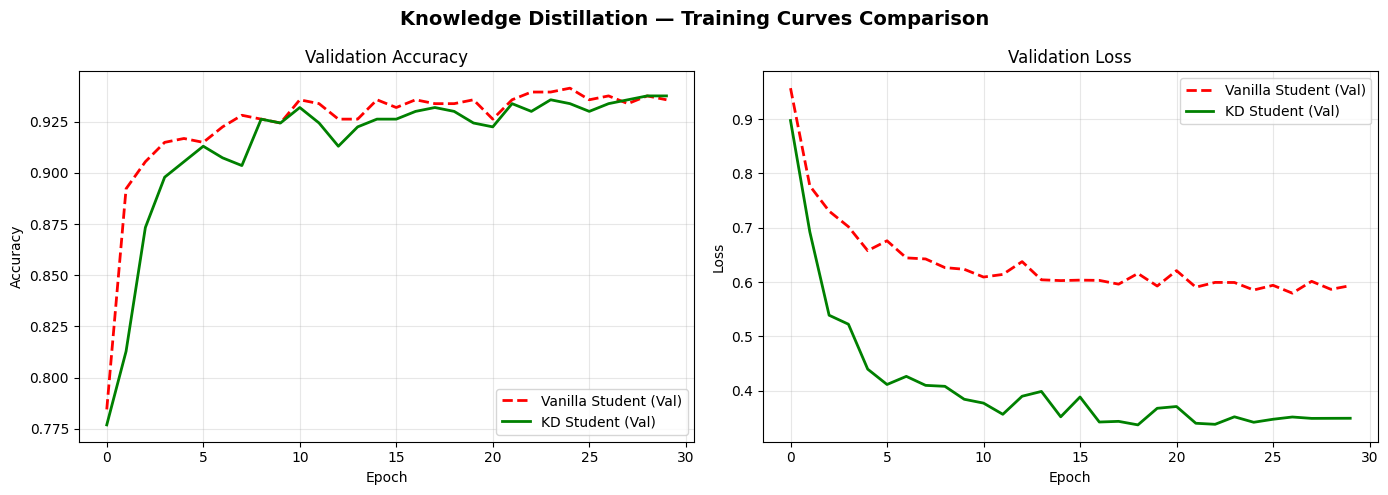

In [36]:
# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Knowledge Distillation — Training Curves Comparison',
             fontsize=14, fontweight='bold')

# Accuracy
ax = axes[0]
ax.plot(history_vanilla.history['val_accuracy'], 'r--', label='Vanilla Student (Val)', linewidth=2)
ax.plot(kd_history['val_accuracy'], 'g-', label='KD Student (Val)', linewidth=2)
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(history_vanilla.history['val_loss'], 'r--', label='Vanilla Student (Val)', linewidth=2)
ax.plot(kd_history['val_loss'], 'g-', label='KD Student (Val)', linewidth=2)
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'kd_comparison_curves.png'), dpi=150)
plt.show()

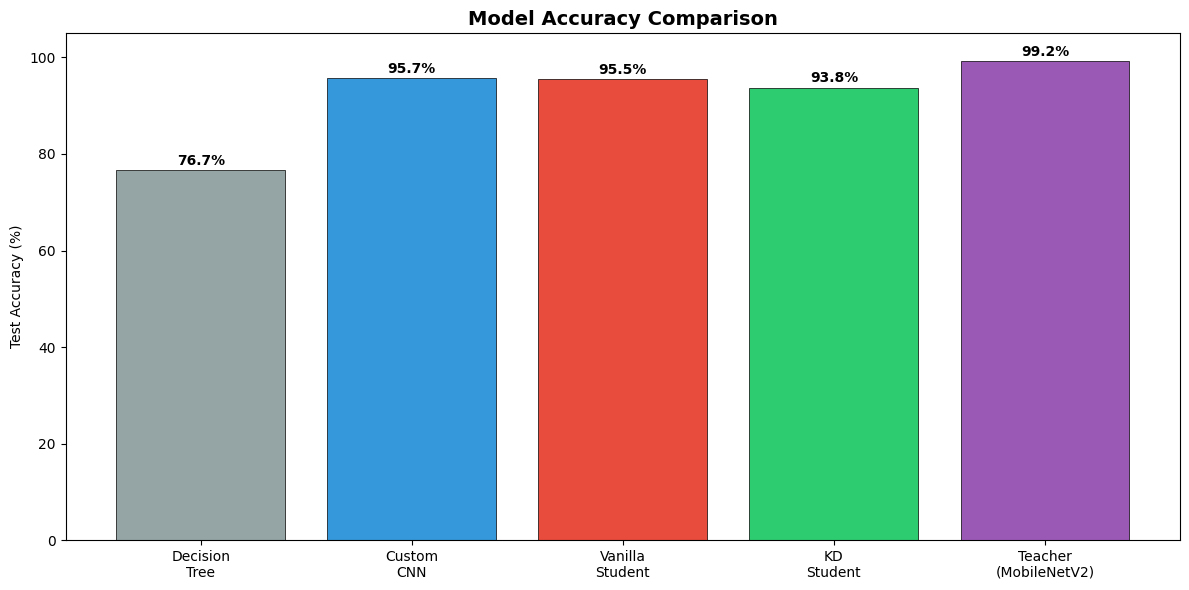

In [37]:
# Accuracy bar chart — all models
plt.figure(figsize=(12, 6))
model_labels = ['Decision\nTree', 'Custom\nCNN', 'Vanilla\nStudent', 'KD\nStudent', 'Teacher\n(MobileNetV2)']
accuracies = [dt_test_acc*100, cnn_acc*100, vanilla_acc*100, kd_acc*100, teacher_acc*100]
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = plt.bar(model_labels, accuracies, color=colors, edgecolor='black', linewidth=0.5)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 105)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'all_models_accuracy.png'), dpi=150)
plt.show()

---
## Section 8: Magnitude-Based Pruning (Lab 09)

We apply **magnitude-based pruning** to the KD student model to further reduce its size.
Pruning zeroes out small-magnitude weights, making the model sparser.

Using `PolynomialDecay` schedule to gradually increase sparsity from 30% → 70%.
This is the same technique from Lab 09 using `tensorflow-model-optimization`.

In [ ]:
kd_student.save("my_trained_student.h5")
print("Model saved safely! You can now restart.")

Model saved safely! You can now restart.


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# ============================================================================
# SECTION 8: MAGNITUDE-BASED PRUNING (Lab 09)
# ============================================================================
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

print("=" * 60)
print("  ITERATIVE PRUNING — 3 Rounds with Retraining")
print("=" * 60)

current_model = kd_student  # Start from KD student

for round_idx, (init_sp, final_sp) in enumerate(PRUNING_ROUNDS):
    print(f"\n--- Pruning Round {round_idx+1}/3: {init_sp*100:.0f}% → {final_sp*100:.0f}% ---")

    num_train_samples = len(X_train)
    end_step = np.ceil(num_train_samples / BATCH_SIZE).astype(np.int32) * EPOCHS_PRUNING_PER_ROUND

    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=init_sp,
            final_sparsity=final_sp,
            begin_step=0,
            end_step=end_step
        )
    }

    model_for_pruning = prune_low_magnitude(current_model, **pruning_params)

    # Lower LR each round
    lr = 1e-4 / (round_idx + 1)
    model_for_pruning.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    log_dir = tempfile.mkdtemp()
    pruning_callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tfmot.sparsity.keras.PruningSummaries(log_dir=log_dir),
    ]

    pruning_history = model_for_pruning.fit(
        X_train, y_train_oh,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_PRUNING_PER_ROUND,
        validation_data=(X_val, y_val_oh),
        callbacks=pruning_callbacks,
        verbose=1
    )

    _, round_acc = model_for_pruning.evaluate(X_test, y_test_oh, verbose=0)
    print(f"  Round {round_idx+1} accuracy: {round_acc*100:.2f}%")

    # Strip and prepare for next round
    current_model = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

# Final pruned model
model_pruned_export = current_model
model_pruned_export.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
_, stripped_acc = model_pruned_export.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nFinal Iterative Pruned Accuracy: {stripped_acc*100:.2f}%")
print(f"KD Student Accuracy (before pruning): {kd_acc*100:.2f}%")
print(f"Accuracy drop: {(kd_acc - stripped_acc)*100:.2f}%")
print(f"Parameters: {model_pruned_export.count_params():,}")

# Verify sparsity
print("\nLayer-wise Sparsity After Iterative Pruning:")
print("-" * 60)
all_weights = []
for layer in model_pruned_export.layers:
    if hasattr(layer, 'kernel'):
        weights = layer.kernel.numpy()
        total = weights.size
        zeros = np.sum(weights == 0)
        sparsity = zeros / total
        print(f"  {layer.name:20s}: {sparsity*100:6.1f}% sparse "
              f"({zeros:,}/{total:,} zeros)")
        all_weights.append(weights.flatten())

if all_weights:
    all_w = np.concatenate(all_weights)
    print(f"\n  Overall sparsity: {np.sum(all_w == 0) / all_w.size * 100:.1f}%")


  ITERATIVE PRUNING — 3 Rounds with Retraining

--- Pruning Round 1/3: 0% → 20% ---
Epoch 1/5
 4/75 [>.............................] - ETA: 1s - loss: 0.8925 - accuracy: 1.0000   

75/75 [==============================] - 14s 26ms/step - loss: 0.7683 - accuracy: 0.9870 - val_loss: 0.7476 - val_accuracy: 0.9550
Epoch 2/5
75/75 [==============================] - 3s 43ms/step - loss: 0.6621 - accuracy: 0.9803 - val_loss: 0.6501 - val_accuracy: 0.9787
Epoch 3/5
75/75 [==============================] - 2s 24ms/step - loss: 0.6107 - accuracy: 0.9803 - val_loss: 0.6753 - val_accuracy: 0.9289
Epoch 4/5
75/75 [==============================] - 3s 34ms/step - loss: 0.5441 - accuracy: 0.9791 - val_loss: 0.6086 - val_accuracy: 0.9597
Epoch 5/5
75/75 [==============================] - 2s 26ms/step - loss: 0.5067 - accuracy: 0.9874 - val_loss: 0.5118 - val_accuracy: 0.9668
  Round 1 accuracy: 98.41%

--- Pruning Round 2/3: 20% → 35% ---
Epoch 1/5
75/75 [==============================] - 12s 43ms/step - loss: 0.4825 - accuracy: 0.9866 - val_loss: 0.4891 - val_accuracy: 0.9739
Epoch 2/5
75/75 [==============================] - 1s 19ms/step - loss: 0.5695 - accuracy: 0.9506 - val

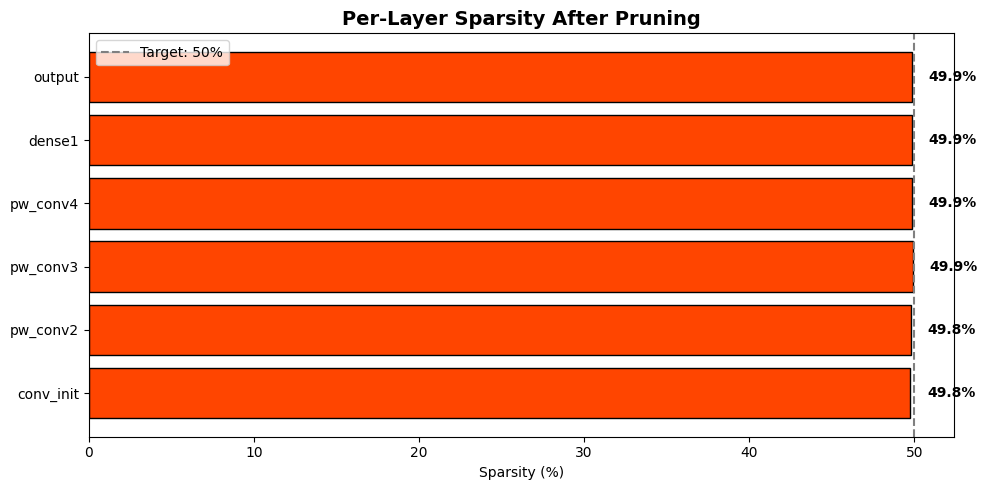

In [ ]:
# Sparsity bar chart
layer_names_sp, sparsities = [], []
for layer in model_for_pruning.layers:
    if hasattr(layer, 'layer') and hasattr(layer.layer, 'kernel'):
        weights = layer.layer.kernel.numpy()
        sp = np.sum(weights == 0) / weights.size
        layer_names_sp.append(layer.layer.name)
        sparsities.append(sp * 100)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(layer_names_sp, sparsities, color='orangered', edgecolor='black')
ax.set_xlabel('Sparsity (%)')
ax.set_title('Per-Layer Sparsity After Pruning', fontsize=14, fontweight='bold')
ax.axvline(x=final_sp*100, color='gray', linestyle='--',
           label=f'Target: {final_sp*100:.0f}%')
ax.legend()

for bar, sp in zip(bars, sparsities):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{sp:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pruning_sparsity.png'), dpi=150)
plt.show()

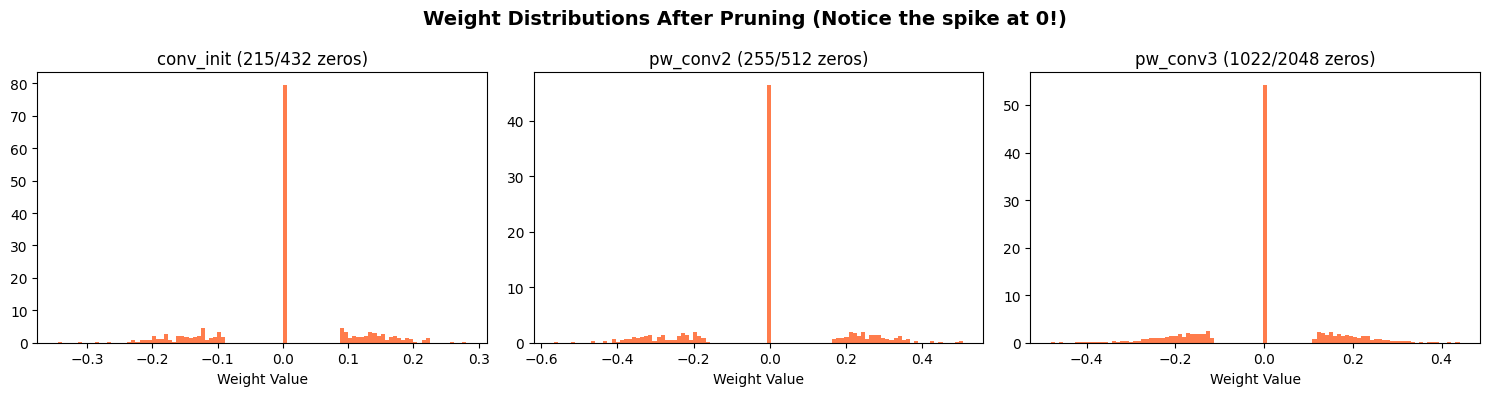

In [ ]:
# Weight distributions AFTER pruning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Weight Distributions After Pruning (Notice the spike at 0!)',
             fontsize=14, fontweight='bold')

plot_idx = 0
for layer in model_for_pruning.layers:
    if hasattr(layer, 'layer') and hasattr(layer.layer, 'kernel') and plot_idx < 3:
        weights = layer.layer.kernel.numpy().flatten()
        axes[plot_idx].hist(weights, bins=100, density=True,
                           color='orangered', alpha=0.7)
        axes[plot_idx].set_title(f'{layer.layer.name} ({np.sum(weights==0)}/{weights.size} zeros)')
        axes[plot_idx].set_xlabel('Weight Value')
        plot_idx += 1

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pruned_weight_distributions.png'), dpi=150)
plt.show()

In [ ]:
# Strip pruning wrappers for export
model_pruned_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

# Verify accuracy is preserved
model_pruned_export.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
_, stripped_acc = model_pruned_export.evaluate(X_test, y_test_oh, verbose=0)
print(f"Accuracy after stripping pruning wrappers: {stripped_acc*100:.2f}%")
print(f"Parameters: {model_pruned_export.count_params():,}")
model_pruned_export.summary()

Accuracy after stripping pruning wrappers: 84.46%
Parameters: 14,188
Model: "student_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_init (Conv2D)          (None, 96, 96, 16)        432       
                                                                 
 bn_init (BatchNormalizatio  (None, 96, 96, 16)        64        
 n)                                                              
                                                                 
 relu_init (ReLU)            (None, 96, 96, 16)        0         
                                                                 
 pool1 (MaxPooling2D)        (None, 48, 48, 16)        0         
                                                                 
 dw_conv2 (DepthwiseConv2D)  (None, 48, 48, 16)        144       
                                                                 
 bn_dw2 (BatchNormalization  (None, 48, 48, 16)   

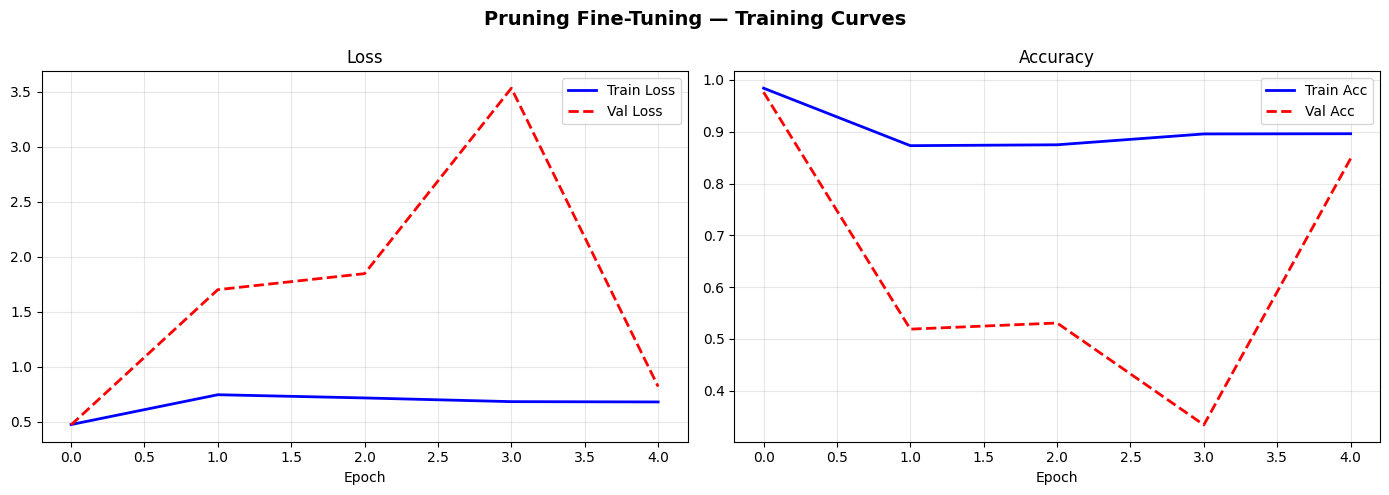

In [ ]:
# Pruning training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pruning Fine-Tuning — Training Curves', fontsize=14, fontweight='bold')

ax1.plot(pruning_history.history['loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(pruning_history.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(pruning_history.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(pruning_history.history['val_accuracy'], 'r--', label='Val Acc', linewidth=2)
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'pruning_training_curves.png'), dpi=150)
plt.show()

---
## Section 9: Quantization Aware Training — QAT (Lab 07/08)

**Quantization Aware Training** simulates quantization during training,
allowing the model to adapt to lower precision (INT8) and maintain accuracy.

This is applied AFTER pruning, creating a **Pruned + QAT** model — the final
model that will be deployed to Arduino Nicla Vision.

In [38]:
model_pruned_export = kd_student  # No pruning
stripped_acc = kd_acc
print(f"Skipping pruning for deployment (Edge Impulse approach)")
print(f"Student accuracy passed to QAT: {kd_acc*100:.2f}%")

Skipping pruning for deployment (Edge Impulse approach)
Student accuracy passed to QAT: 93.77%


In [39]:
# ============================================================================
# SECTION 9: QUANTIZATION AWARE TRAINING (Lab 07/08)
# ============================================================================

# Apply QAT to the pruned-stripped model
quant_aware_model = tfmot.quantization.keras.quantize_model(model_pruned_export)

quant_aware_model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("Quantization Aware Training Model:")
quant_aware_model.summary()
print(f"\nQAT model parameters: {quant_aware_model.count_params():,}")

print("Fine-tuning with Quantization Aware Training...")
print("=" * 50)

Quantization Aware Training Model:
Model: "student_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 96, 96, 3)         3         
 yer)                                                            
                                                                 
 quant_conv1 (QuantizeWrapp  (None, 96, 96, 16)        483       
 erV2)                                                           
                                                                 
 quant_pool1 (QuantizeWrapp  (None, 48, 48, 16)        1         
 erV2)                                                           
                                                                 
 quant_conv2 (QuantizeWrapp  (None, 48, 48, 32)        4707      
 erV2)                                                           
                                                                 
 quant_pool2 (Quan

In [40]:
qat_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

qat_history = quant_aware_model.fit(
    X_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_QAT,
    validation_data=(X_val, y_val_oh),
    callbacks=qat_callbacks,
    verbose=1
)

_, qat_acc = quant_aware_model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nQAT Model Test Accuracy: {qat_acc*100:.2f}%")
print(f"Pruned Model Accuracy:   {stripped_acc*100:.2f}%")
print(f"KD Student Accuracy:     {kd_acc*100:.2f}%")
print(f"Accuracy change (QAT vs Pruned): {(qat_acc - stripped_acc)*100:+.2f}%")

Epoch 1/15
94/94 [==============================] - 3s 16ms/step - loss: 0.4520 - accuracy: 0.9843 - val_loss: 0.6770 - val_accuracy: 0.9282 - lr: 2.0000e-05
Epoch 2/15
94/94 [==============================] - 1s 12ms/step - loss: 0.4713 - accuracy: 0.9907 - val_loss: 0.7253 - val_accuracy: 0.9187 - lr: 2.0000e-05
Epoch 3/15
94/94 [==============================] - 1s 12ms/step - loss: 0.4878 - accuracy: 0.9897 - val_loss: 0.7311 - val_accuracy: 0.9225 - lr: 2.0000e-05
Epoch 4/15
90/94 [===========================>..] - ETA: 0s - loss: 0.5001 - accuracy: 0.9861
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
94/94 [==============================] - 1s 12ms/step - loss: 0.5008 - accuracy: 0.9863 - val_loss: 0.7897 - val_accuracy: 0.9168 - lr: 2.0000e-05
Epoch 5/15
94/94 [==============================] - 1s 16ms/step - loss: 0.5313 - accuracy: 0.9883 - val_loss: 0.8624 - val_accuracy: 0.9074 - lr: 1.0000e-05
Epoch 6/15
94/94 [==============================] -

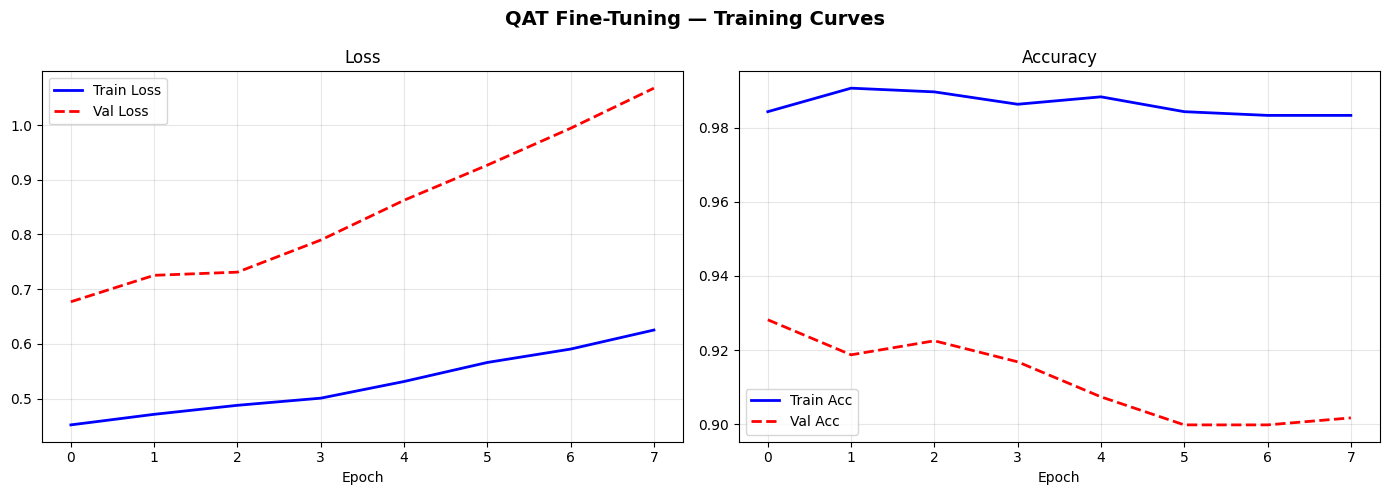

In [41]:
# QAT Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('QAT Fine-Tuning — Training Curves', fontsize=14, fontweight='bold')

ax1.plot(qat_history.history['loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(qat_history.history['val_loss'], 'r--', label='Val Loss', linewidth=2)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(qat_history.history['accuracy'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(qat_history.history['val_accuracy'], 'r--', label='Val Acc', linewidth=2)
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'qat_training_curves.png'), dpi=150)
plt.show()

---
## Section 10: TFLite Conversion & INT8 Quantization (Lab 07/08)

We convert multiple models to TensorFlow Lite format with full INT8 quantization.
The INT8 model is what will run on the Arduino Nicla Vision using TF-Lite Micro.

**Key considerations for Nicla Vision:**
- Model must be < 300KB to fit in flash
- INT8 inference (no floating point unit used)
- Input/output quantized to uint8

In [42]:
# ============================================================================
# SECTION 10: TFLITE CONVERSION & INT8 QUANTIZATION (Lab 07/08)
# ============================================================================

def representative_dataset_gen():
    """Generate representative dataset for full INT8 calibration.
    Uses 500 samples (was 200) for better quantization accuracy.
    """
    num_calibration = min(500, len(X_train))
    indices = np.random.choice(len(X_train), num_calibration, replace=False)
    for idx in indices:
        sample = X_train[idx:idx+1].astype(np.float32)
        yield [sample]

def convert_to_tflite(model, model_name, quantize_int8=False):
    """Convert a Keras model to TFLite format."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if quantize_int8:
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8

    tflite_model = converter.convert()

    tflite_path = os.path.join(OUTPUT_PATH, f'{model_name}.tflite')
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)

    size_kb = len(tflite_model) / 1024
    print(f"  {model_name}: {size_kb:.1f} KB → {tflite_path}")
    return tflite_model, tflite_path, size_kb

print("Converting models to TFLite...")
print("=" * 50)


Converting models to TFLite...


In [43]:
# 1. Custom CNN — Float32 TFLite
print("\n1. Custom CNN (Float32):")
tflite_cnn, tflite_cnn_path, size_cnn = convert_to_tflite(
    model_cnn, 'custom_cnn_float32', quantize_int8=False
)


1. Custom CNN (Float32):
  custom_cnn_float32: 439.4 KB → /content/drive/MyDrive/edge_ai_project/output/custom_cnn_float32.tflite


In [44]:
# 2. KD Student — Float32 TFLite
print("2. KD Student (Float32):")
tflite_kd, tflite_kd_path, size_kd = convert_to_tflite(
    kd_student, 'kd_student_float32', quantize_int8=False
)

2. KD Student (Float32):
  kd_student_float32: 454.8 KB → /content/drive/MyDrive/edge_ai_project/output/kd_student_float32.tflite


In [45]:
# 3. Pruned KD Student — Float32 TFLite
print("3. Pruned KD Student (Float32):")
tflite_pruned, tflite_pruned_path, size_pruned = convert_to_tflite(
    model_pruned_export, 'pruned_kd_student_float32', quantize_int8=False
)

3. Pruned KD Student (Float32):
  pruned_kd_student_float32: 454.8 KB → /content/drive/MyDrive/edge_ai_project/output/pruned_kd_student_float32.tflite


In [46]:
# 4. FINAL MODEL: Pruned + QAT + INT8 — This goes on the Nicla Vision!
print("4. Pruned + QAT + INT8 (DEPLOYMENT MODEL):")
tflite_final, tflite_final_path, size_final = convert_to_tflite(
    quant_aware_model, 'blind_assist_int8', quantize_int8=True
)

print(f"\n{'='*50}")
print(f"FINAL DEPLOYMENT MODEL: {size_final:.1f} KB")
if size_final < 300:
    print(f"✅ Model fits in Nicla Vision flash (<300KB)!")
else:
    print(f"⚠️ Model is too large for Nicla Vision! Need further optimization.")
print(f"{'='*50}")

4. Pruned + QAT + INT8 (DEPLOYMENT MODEL):


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  blind_assist_int8: 118.2 KB → /content/drive/MyDrive/edge_ai_project/output/blind_assist_int8.tflite

FINAL DEPLOYMENT MODEL: 118.2 KB
✅ Model fits in Nicla Vision flash (<300KB)!


In [47]:
# Evaluate TFLite models using TFLite Interpreter

def evaluate_tflite(tflite_model_content, x_test, y_test, is_quantized=False):
    """Run inference on test set using TFLite interpreter."""
    interpreter = tf.lite.Interpreter(model_content=tflite_model_content)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    predictions = []
    inference_times = []

    for i in range(len(x_test)):
        input_data = x_test[i:i+1].astype(np.float32)

        if is_quantized:
            # Quantize input to uint8
            input_scale = input_details[0]['quantization'][0]
            input_zero_point = input_details[0]['quantization'][1]
            input_data = (input_data / input_scale + input_zero_point).astype(np.uint8)

        interpreter.set_tensor(input_details[0]['index'], input_data)

        start = time.time()
        interpreter.invoke()
        inference_times.append(time.time() - start)

        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(np.argmax(output[0]))

    accuracy = accuracy_score(y_test, predictions)
    avg_time = np.mean(inference_times[1:]) * 1000  # Skip first (warm-up)

    return accuracy, avg_time

print("Evaluating TFLite models...")
print("=" * 60)

acc_tflite_cnn, time_tflite_cnn = evaluate_tflite(tflite_cnn, X_test, y_test)
print(f"  Custom CNN (Float32):     {acc_tflite_cnn*100:.2f}% | {time_tflite_cnn:.2f}ms")

acc_tflite_kd, time_tflite_kd = evaluate_tflite(tflite_kd, X_test, y_test)
print(f"  KD Student (Float32):     {acc_tflite_kd*100:.2f}% | {time_tflite_kd:.2f}ms")

acc_tflite_pruned, time_tflite_pruned = evaluate_tflite(tflite_pruned, X_test, y_test)
print(f"  Pruned Student (Float32): {acc_tflite_pruned*100:.2f}% | {time_tflite_pruned:.2f}ms")

acc_tflite_final, time_tflite_final = evaluate_tflite(tflite_final, X_test, y_test, is_quantized=True)
print(f"  Final INT8 (Deploy):      {acc_tflite_final*100:.2f}% | {time_tflite_final:.2f}ms")

print("=" * 60)

Evaluating TFLite models...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Custom CNN (Float32):     95.69% | 1.96ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  KD Student (Float32):     93.77% | 0.61ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Pruned Student (Float32): 93.77% | 0.62ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  Final INT8 (Deploy):      91.21% | 0.78ms


---
## Section 11: Final Comparison Dashboard

Comprehensive comparison of all models across all metrics.

In [48]:
# ============================================================================
# SECTION 11: FINAL COMPARISON DASHBOARD
# ============================================================================

import pandas as pd

# Build comprehensive comparison table
comparison_data = {
    'Model': [
        'Decision Tree',
        'Custom CNN',
        'MobileNetV2 (Teacher)',
        'Vanilla Student (No KD)',
        'KD Student',
        'Pruned KD Student',
        'Pruned + QAT Student',
        'Final INT8 TFLite'
    ],
    'Test Accuracy (%)': [
        dt_test_acc * 100,
        cnn_acc * 100,
        teacher_acc * 100,
        vanilla_acc * 100,
        kd_acc * 100,
        stripped_acc * 100,
        qat_acc * 100,
        acc_tflite_final * 100
    ],
    'Parameters': [
        'N/A',
        f"{model_cnn.count_params():,}",
        f"{teacher_model.count_params():,}",
        f"{vanilla_student.count_params():,}",
        f"{kd_student.count_params():,}",
        f"{model_pruned_export.count_params():,}",
        f"{model_pruned_export.count_params():,}",
        f"{model_pruned_export.count_params():,}"
    ],
    'TFLite Size (KB)': [
        'N/A',
        f"{size_cnn:.1f}",
        'N/A (too large)',
        'N/A',
        f"{size_kd:.1f}",
        f"{size_pruned:.1f}",
        'N/A',
        f"{size_final:.1f}"
    ],
    'Technique': [
        'Lab 04',
        'Lab 05',
        'Lab 05 (Transfer)',
        'Lab 05',
        'Lab 10 (KD)',
        'Lab 09 (Pruning)',
        'Lab 08 (QAT)',
        'Lab 07 (INT8 Quant)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "=" * 90)
print("              FINAL MODEL COMPARISON DASHBOARD")
print("=" * 90)
print(df_comparison.to_string(index=False))
print("=" * 90)

# Save to CSV
df_comparison.to_csv(os.path.join(OUTPUT_PATH, 'model_comparison.csv'), index=False)
print(f"\nComparison table saved to {OUTPUT_PATH}/model_comparison.csv")


              FINAL MODEL COMPARISON DASHBOARD
                  Model  Test Accuracy (%) Parameters TFLite Size (KB)           Technique
          Decision Tree          76.677316        N/A              N/A              Lab 04
             Custom CNN          95.686901    111,622            439.4              Lab 05
  MobileNetV2 (Teacher)          99.201280  2,422,726  N/A (too large)   Lab 05 (Transfer)
Vanilla Student (No KD)          95.527154    115,686              N/A              Lab 05
             KD Student          93.769968    115,686            454.8         Lab 10 (KD)
      Pruned KD Student          93.769968    115,686            454.8    Lab 09 (Pruning)
   Pruned + QAT Student          91.373801    115,686              N/A        Lab 08 (QAT)
      Final INT8 TFLite          91.214058    115,686            118.2 Lab 07 (INT8 Quant)

Comparison table saved to /content/drive/MyDrive/edge_ai_project/output/model_comparison.csv


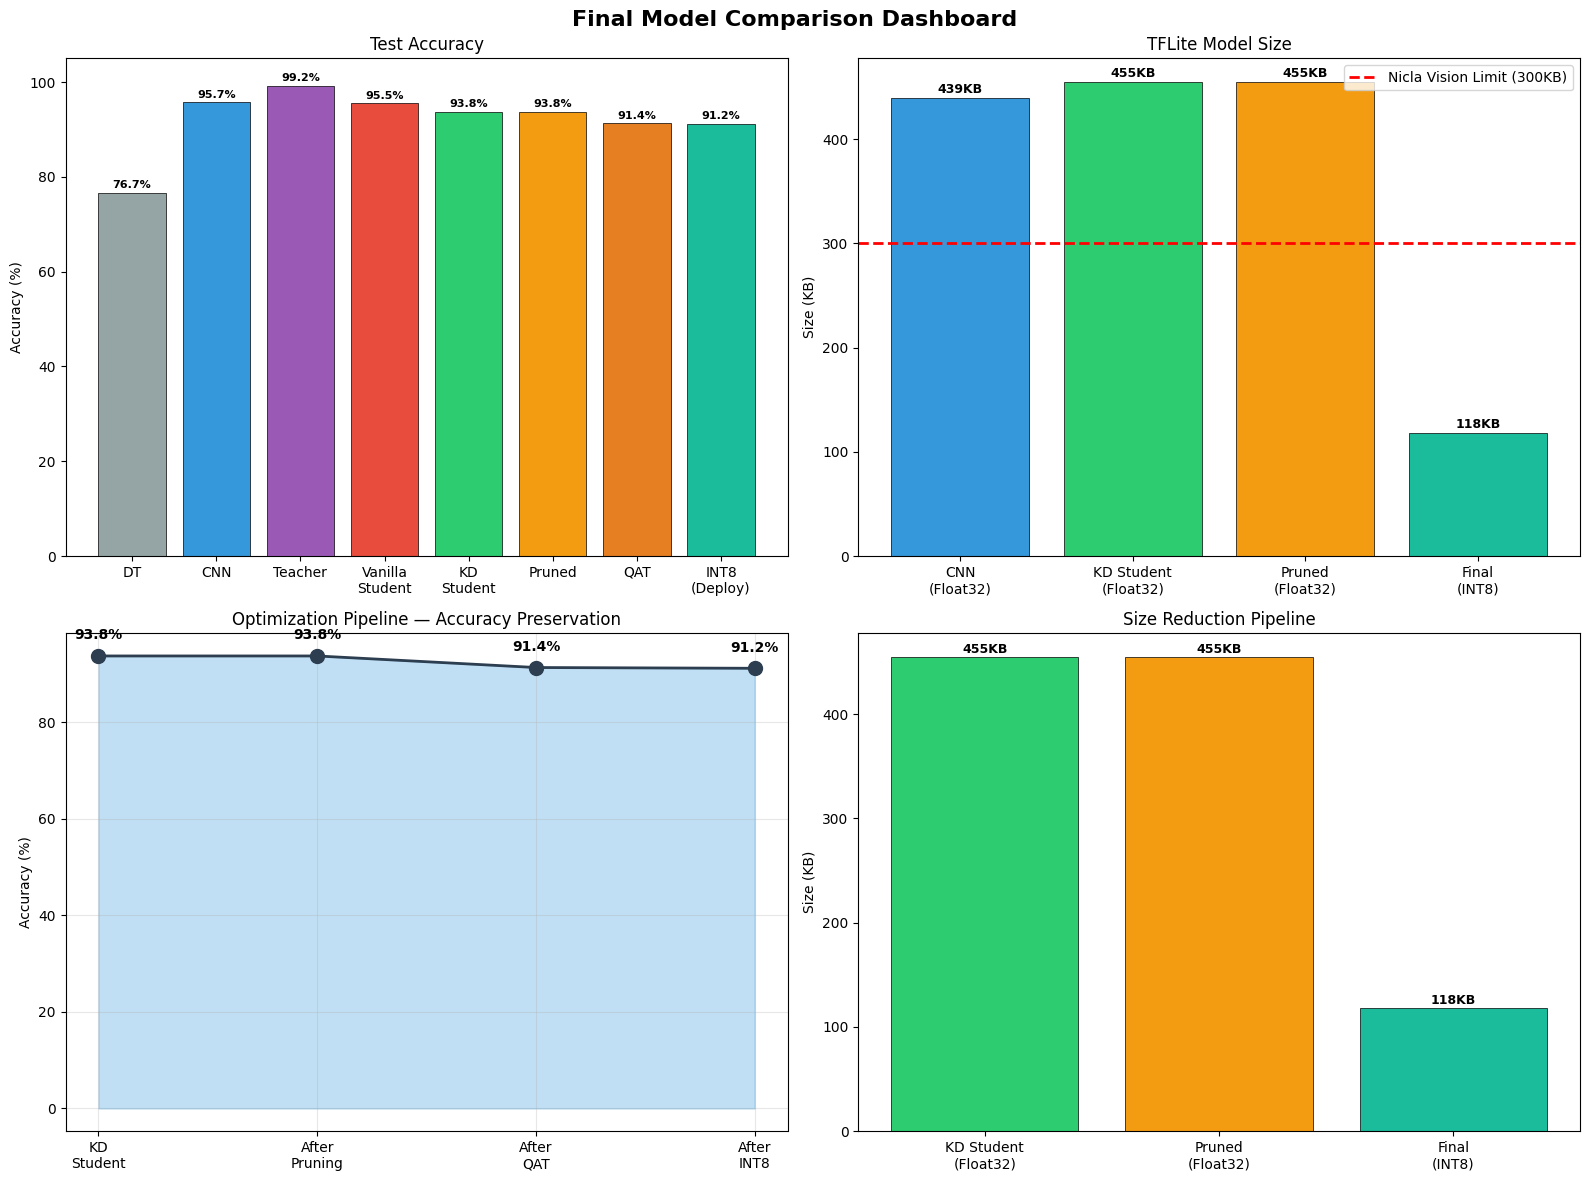

In [49]:
# Final comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Final Model Comparison Dashboard',
             fontsize=16, fontweight='bold')

# 1. Accuracy Comparison
ax = axes[0, 0]
model_labels_short = ['DT', 'CNN', 'Teacher', 'Vanilla\nStudent', 'KD\nStudent',
                       'Pruned', 'QAT', 'INT8\n(Deploy)']
accs = [dt_test_acc*100, cnn_acc*100, teacher_acc*100, vanilla_acc*100,
        kd_acc*100, stripped_acc*100, qat_acc*100, acc_tflite_final*100]
colors_all = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c',
              '#2ecc71', '#f39c12', '#e67e22', '#1abc9c']
bars = ax.bar(model_labels_short, accs, color=colors_all,
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy')
ax.set_ylim(0, 105)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 2. Model Size Comparison (TFLite)
ax = axes[0, 1]
size_labels = ['CNN\n(Float32)', 'KD Student\n(Float32)', 'Pruned\n(Float32)', 'Final\n(INT8)']
sizes = [size_cnn, size_kd, size_pruned, size_final]
size_colors = ['#3498db', '#2ecc71', '#f39c12', '#1abc9c']
bars = ax.bar(size_labels, sizes, color=size_colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Size (KB)')
ax.set_title('TFLite Model Size')
ax.axhline(y=300, color='red', linestyle='--', linewidth=2, label='Nicla Vision Limit (300KB)')
ax.legend()
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{s:.0f}KB', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Optimization Pipeline
ax = axes[1, 0]
pipeline_labels = ['KD\nStudent', 'After\nPruning', 'After\nQAT', 'After\nINT8']
pipeline_accs = [kd_acc*100, stripped_acc*100, qat_acc*100, acc_tflite_final*100]
pipeline_colors = ['#2ecc71', '#f39c12', '#e67e22', '#1abc9c']
ax.plot(pipeline_labels, pipeline_accs, 'o-', color='#2c3e50',
        linewidth=2, markersize=10)
ax.fill_between(range(len(pipeline_labels)), pipeline_accs,
                alpha=0.3, color='#3498db')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Optimization Pipeline — Accuracy Preservation')
ax.grid(True, alpha=0.3)
for i, (label, acc) in enumerate(zip(pipeline_labels, pipeline_accs)):
    ax.annotate(f'{acc:.1f}%', (i, acc), textcoords='offset points',
                xytext=(0, 12), ha='center', fontweight='bold')

# 4. Size reduction pipeline
ax = axes[1, 1]
size_pipeline = [size_kd, size_pruned, size_final]
size_pipeline_labels = ['KD Student\n(Float32)', 'Pruned\n(Float32)', 'Final\n(INT8)']
bars = ax.bar(size_pipeline_labels, size_pipeline,
              color=['#2ecc71', '#f39c12', '#1abc9c'],
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Size (KB)')
ax.set_title('Size Reduction Pipeline')
for bar, s in zip(bars, size_pipeline):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{s:.0f}KB', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'final_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Final INT8 TFLite Model — Classification Report:
              precision    recall  f1-score   support

  clear_path      0.818     0.887     0.851        71
        door      0.948     0.958     0.953        95
       human      1.000     0.900     0.947        70
      object      0.934     0.881     0.906       176
    obstacle      0.814     0.905     0.857       116
      stairs      0.989     0.959     0.974        98

    accuracy                          0.912       626
   macro avg      0.917     0.915     0.915       626
weighted avg      0.917     0.912     0.913       626



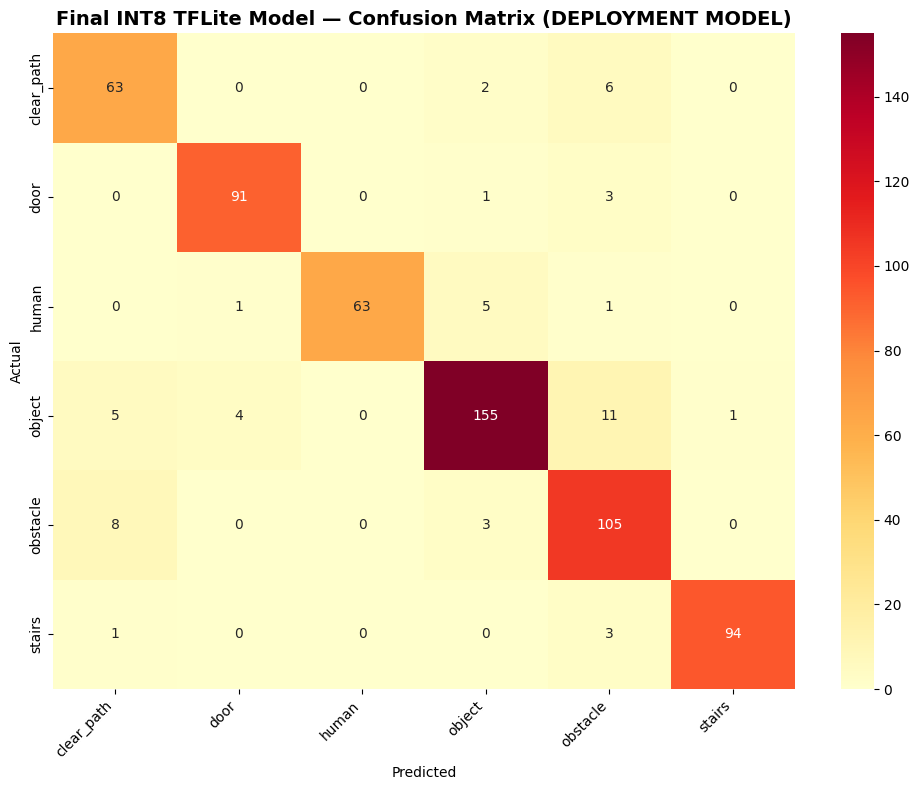

In [50]:
# Final model confusion matrix
# We already evaluated tflite_final — let's get detailed predictions

interpreter = tf.lite.Interpreter(model_content=tflite_final)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

final_predictions = []
for i in range(len(X_test)):
    input_data = X_test[i:i+1].astype(np.float32)
    input_scale = input_details[0]['quantization'][0]
    input_zero_point = input_details[0]['quantization'][1]
    input_data = (input_data / input_scale + input_zero_point).astype(np.uint8)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    final_predictions.append(np.argmax(output[0]))

final_predictions = np.array(final_predictions)

print("Final INT8 TFLite Model — Classification Report:")
print("=" * 60)
print(classification_report(y_test, final_predictions,
                            target_names=class_names, digits=3))

# Confusion Matrix
cm_final = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final INT8 TFLite Model — Confusion Matrix (DEPLOYMENT MODEL)',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'final_confusion_matrix.png'), dpi=150)
plt.show()

---
## Section 12: Export for Arduino Nicla Vision Deployment

We prepare everything needed for deployment:
1. Save the final `.tflite` model
2. Create `labels.txt` with class names
3. Convert to C byte array (for Arduino sketch deployment)
4. Provide download links

In [51]:
# ============================================================================
# SECTION 12: EXPORT FOR ARDUINO NICLA VISION DEPLOYMENT
# ============================================================================

# 1. Save labels.txt
labels_path = os.path.join(OUTPUT_PATH, 'labels.txt')
with open(labels_path, 'w') as f:
    for cls in class_names:
        f.write(f"{cls}\n")
print(f"Labels saved to: {labels_path}")
print(f"Classes: {class_names}")

# 2. Convert TFLite to C header for Arduino
def tflite_to_c_array(tflite_path, output_path, array_name='model_data'):
    """Convert a .tflite model file to a C byte array header file."""
    with open(tflite_path, 'rb') as f:
        model_bytes = f.read()

    c_array = ', '.join([f'0x{b:02x}' for b in model_bytes])

    header_content = f"""// Auto-generated TFLite model data
// Model: AI-Powered Blind Assistance Device
// Size: {len(model_bytes)} bytes ({len(model_bytes)/1024:.1f} KB)
// Input: {IMG_SIZE}x{IMG_SIZE}x3 uint8
// Output: {NUM_CLASSES} classes
// Classes: {', '.join(class_names)}

#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned int {array_name}_len = {len(model_bytes)};
alignas(8) const unsigned char {array_name}[] = {{
  {c_array}
}};

#endif // MODEL_DATA_H
"""

    with open(output_path, 'w') as f:
        f.write(header_content)

    print(f"C header saved to: {output_path}")
    print(f"Array size: {len(model_bytes)} bytes")

# Generate C header
c_header_path = os.path.join(OUTPUT_PATH, 'model_data.h')
tflite_to_c_array(tflite_final_path, c_header_path)

# 3. Generate labels header
labels_h_path = os.path.join(OUTPUT_PATH, 'labels.h')
labels_h_content = f"""// Auto-generated labels for AI-Powered Blind Assistance Device
#ifndef LABELS_H
#define LABELS_H

const int NUM_CLASSES = {NUM_CLASSES};
const char* CLASS_NAMES[] = {{
  {', '.join([f'"{c}"' for c in class_names])}
}};

#endif // LABELS_H
"""

with open(labels_h_path, 'w') as f:
    f.write(labels_h_content)
print(f"Labels header saved to: {labels_h_path}")

Labels saved to: /content/drive/MyDrive/edge_ai_project/output/labels.txt
Classes: ['clear_path', 'door', 'human', 'object', 'obstacle', 'stairs']
C header saved to: /content/drive/MyDrive/edge_ai_project/output/model_data.h
Array size: 121064 bytes
Labels header saved to: /content/drive/MyDrive/edge_ai_project/output/labels.h


In [52]:
# 4. Create a ZIP bundle for easy download
zip_path = os.path.join(OUTPUT_PATH, 'nicla_vision_deployment.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(tflite_final_path, 'blind_assist_int8.tflite')
    zf.write(labels_path, 'labels.txt')
    zf.write(c_header_path, 'model_data.h')
    zf.write(labels_h_path, 'labels.h')

print(f"\nDeployment bundle created: {zip_path}")
print(f"Contents:")
print(f"  - blind_assist_int8.tflite  ({size_final:.1f} KB)")
print(f"  - labels.txt")
print(f"  - model_data.h (for Arduino sketch)")
print(f"  - labels.h (for Arduino sketch)")


Deployment bundle created: /content/drive/MyDrive/edge_ai_project/output/nicla_vision_deployment.zip
Contents:
  - blind_assist_int8.tflite  (118.2 KB)
  - labels.txt
  - model_data.h (for Arduino sketch)
  - labels.h (for Arduino sketch)


In [53]:
# Download the deployment bundle
from google.colab import files

print("Downloading deployment files...")
files.download(zip_path)
print("\nAlso downloading individual files:")
files.download(tflite_final_path)
files.download(labels_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Also downloading individual files:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("    AI-POWERED BLIND ASSISTANCE DEVICE — PROJECT SUMMARY")
print("=" * 70)
print(f"\n  Dataset: {total_samples} images across {NUM_CLASSES} classes")
print(f"  Input Size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"\n  Model Performance:")
print(f"  Decision Tree (Lab 04):         {dt_test_acc*100:.2f}%")
print(f"  Custom CNN (Lab 05):             {cnn_acc*100:.2f}%")
print(f"  Teacher MobileNetV2 (Lab 05):    {teacher_acc*100:.2f}%")
print(f"  V. Student (Lab 05):             {vanilla_acc*100:.2f}%")
print(f"  KD Student (Lab 10):             {kd_acc*100:.2f}%")
print(f"  Pruned Student (Lab 09):         {stripped_acc*100:.2f}%")
print(f"  QAT Student (Lab 08):            {qat_acc*100:.2f}%")
print(f"  Final INT8 TFLite (Lab 07):      {acc_tflite_final*100:.2f}%")
print(f"\n  Deployment Model:")
print(f"  Size: {size_final:.1f} KB")
print(f"  Format: INT8 TFLite")
print(f"  Target: Arduino Nicla Vision")
print(f"\n  CNN TFLite (Float32): {size_cnn:.1f} KB {'> 300KB!' if size_cnn > 300 else ''}")
print(f"  Final INT8 TFLite:    {size_final:.1f} KB {'< 300KB ✅' if size_final < 300 else '⚠️'}")
print(f"\n  All files saved to: {OUTPUT_PATH}")
print("=" * 70)



    AI-POWERED BLIND ASSISTANCE DEVICE — PROJECT SUMMARY

  Dataset: 4151 images across 6 classes
  Input Size: 96x96x3

  Model Performance:
  Decision Tree (Lab 04):         76.68%
  Custom CNN (Lab 05):             95.69%
  Teacher MobileNetV2 (Lab 05):    99.20%
  V. Student (Lab 05):             95.53%
  KD Student (Lab 10):             93.77%
  Pruned Student (Lab 09):         93.77%
  QAT Student (Lab 08):            91.37%
  Final INT8 TFLite (Lab 07):      91.21%

  Deployment Model:
  Size: 118.2 KB
  Format: INT8 TFLite
  Target: Arduino Nicla Vision

  CNN TFLite (Float32): 439.4 KB > 300KB!
  Final INT8 TFLite:    118.2 KB < 300KB ✅

  All files saved to: /content/drive/MyDrive/edge_ai_project/output


---
## 🎉 Project Complete!

### Next Steps:
1. **Download** `nicla_vision_deployment.zip` from Google Drive
2. **Copy** `blind_assist_int8.tflite` and `labels.txt` to the Nicla Vision
3. **Open** OpenMV IDE and connect to Nicla Vision
4. **Run** the deployment script (`nicla_vision_blind_assist.py`)
5. **Mount** on helmet and demo!

### Techniques Summary:
| Step | Technique | Lab |
|------|-----------|-----|
| Data Handling | Image augmentation, preprocessing | Lab 03 |
| Baseline | Decision Tree | Lab 04 |
| CNN Training | Custom CNN + Transfer Learning | Lab 05 |
| Metrics | Parameters, FLOPs, MACs | Lab 06 |
| Knowledge Distillation | Teacher → Student | Lab 10 |
| Pruning | Magnitude-based, PolynomialDecay | Lab 09 |
| QAT | Fake quantization during training | Lab 08 |
| Quantization | Full INT8 TFLite | Lab 07 |
| Deployment | TF-Lite Micro on Nicla Vision | Lab 02 |